# ABSA-FMI: Multi-Output LSTM Model Training



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_DIR = '/content/drive/MyDrive/ABSA_LSTM'
for f in ['best_model_absa.keras', 'best_model_absa_phase2.keras']:
    path = f'{DRIVE_DIR}/{f}'
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1024 / 1024
        from datetime import datetime
        mtime = os.path.getmtime(path)
        print(f'[OK] {f} — {size_mb:.1f} MB — terakhir diubah: {datetime.fromtimestamp(mtime)}')
    else:
        print(f'[X] {f} TIDAK DITEMUKAN')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[OK] best_model_absa.keras — 6.7 MB — terakhir diubah: 2026-07-20 05:42:13
[X] best_model_absa_phase2.keras TIDAK DITEMUKAN


## Cell 1 — Install Library

In [ ]:
# Install dependencies
# Install Sastrawi (stemmer Bahasa Indonesia) dan library pendukung
!pip install PySastrawi -q
!pip install gensim -q
!pip install openpyxl -q
!pip install scikit-learn -q
!pip install iterative-stratification -q   # Multilabel stratified split

print('[OK] Semua library berhasil diinstall')


[OK] Semua library berhasil diinstall


## Cell 2 — Import Library

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import re
import json
import os
import pickle
import warnings
from collections import Counter
warnings.filterwarnings('ignore')

# Reproducibility (seed terkunci)
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# NLP - Bahasa Indonesia
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Word Embedding
from gensim.models import Word2Vec

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, Callback

tf.random.set_seed(SEED)

# Machine Learning & Evaluasi
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.utils.class_weight import compute_class_weight

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

print(f'TensorFlow : {tf.__version__}')
print(f'Keras      : {keras.__version__}')
print('[OK] Semua library berhasil diimport (seed terkunci = 42)')


TensorFlow : 2.20.0
Keras      : 3.13.2
[OK] Semua library berhasil diimport (seed terkunci = 42)


## Cell 3 — Load Dataset

In [ ]:
# Load dataset

import os, glob, re
from pathlib import Path

try:
    from google.colab import drive
    if not os.path.exists('/content/drive/MyDrive'):
        drive.mount('/content/drive')
except ImportError:
    pass

CARI_DI = [
    Path('/content/drive/MyDrive/Dataset'),
    Path('/content/drive/MyDrive'),
    Path('/content/Dataset'),
    Path('/content'),
    Path('Dataset'),
    Path('.'),
]

ASPECTS    = ['kualitas', 'bahan', 'ukuran', 'desain', 'warna', 'kenyamanan']
ASPEK_COLS = [f'aspek_{a}' for a in ASPECTS]
KOLOM_WAJIB = ['ulasan'] + ASPEK_COLS

def versi(p):
    """dataset_labeled_v6.xlsx -> 6 ; tanpa nomor versi -> -1"""
    m = re.search(r'_v(\d+)', Path(p).stem, re.IGNORECASE)
    return int(m.group(1)) if m else -1

kandidat = []
for d in CARI_DI:
    if d.exists():
        kandidat += glob.glob(str(d / 'dataset_labeled*.xlsx'))
kandidat = sorted(set(kandidat), key=versi, reverse=True)

if not kandidat:
    raise FileNotFoundError(
        "Tidak ditemukan dataset_labeled*.xlsx.\n"
        "Unggah dataset_labeled_v6.xlsx ke salah satu lokasi berikut:\n  - "
        + "\n  - ".join(str(d) for d in CARI_DI)
        + "\nAtau lewat panel Files Colab (ikon folder di sebelah kiri)."
    )

print("Kandidat dataset ditemukan (urut versi terbaru):")
for c in kandidat:
    vv = versi(c)
    print(f"   v{vv if vv >= 0 else '?'}  {c}")

FILE_PATH = None
for c in kandidat:
    try:
        cek = pd.read_excel(c, nrows=3)
        kurang = [k for k in KOLOM_WAJIB if k not in cek.columns]
        if kurang:
            print(f"   [LEWAT] {Path(c).name} - kolom kurang: {kurang}")
            continue
        FILE_PATH = c
        break
    except Exception as e:
        print(f"   [LEWAT] {Path(c).name} - gagal dibaca: {e}")

if FILE_PATH is None:
    raise ValueError("Ada berkas dataset_labeled*.xlsx tetapi tidak ada yang kolomnya lengkap.")

df = pd.read_excel(FILE_PATH)

print(f"\n[OK] Dataset dipakai : {FILE_PATH}")
print(f"     ukuran          : {len(df):,} baris x {len(df.columns)} kolom")

v = versi(FILE_PATH)
if 0 <= v < 6:
    print("\n" + "!" * 64)
    print(f"  PERINGATAN: yang terpilih versi v{v}, bukan v6.")
    print("  Presisi kelas negatif v5 hanya 40% (v6: 62%).")
    print("  Pindahkan berkas versi lama keluar dari folder, lalu ulangi sel ini.")
    print("!" * 64)

nilai_unik = set()
for c in ASPEK_COLS:
    nilai_unik |= set(df[c].dropna().astype(str).str.lower().unique())
print(f"     skema label     : {'netral/positif/negatif' if 'netral' in nilai_unik else 'NaN/positif/negatif'}")
print(f"     nilai ditemukan : {sorted(nilai_unik)}")

if 'pola_ulasan' not in df.columns:
    df['pola_ulasan'] = 'tidak diketahui'
if 'memiliki_label' not in df.columns:
    _low = df[ASPEK_COLS].astype(str).apply(lambda s: s.str.lower())
    df['memiliki_label'] = ((_low != 'netral') & (_low != 'nan')).any(axis=1)

print(f"\nDistribusi pola ulasan:")
print(df['pola_ulasan'].value_counts().to_string())
print(f"\nUlasan dengan >=1 aspek dinilai : {df['memiliki_label'].sum():,}")
print(f"Ulasan tanpa aspek dinilai      : {(~df['memiliki_label']).sum():,}")

print(f"\nDistribusi label per aspek:")
for a, col in zip(ASPECTS, ASPEK_COLS):
    vc = df[col].fillna('netral').astype(str).str.lower().value_counts()
    print(f"  {a:<12} netral {vc.get('netral', 0):>5} | "
          f"positif {vc.get('positif', 0):>5} | negatif {vc.get('negatif', 0):>5}")

print(f"\nSample (2 baris):")
print(df[['ulasan'] + ASPEK_COLS].head(2).to_string())

Kandidat dataset ditemukan (urut versi terbaru):
   v6  /content/drive/MyDrive/Dataset/dataset_labeled_v6.xlsx

[OK] Dataset dipakai : /content/drive/MyDrive/Dataset/dataset_labeled_v6.xlsx
     ukuran          : 6,158 baris x 12 kolom
     skema label     : netral/positif/negatif
     nilai ditemukan : ['negatif', 'netral', 'positif']

Distribusi pola ulasan:
pola_ulasan
terstruktur    3633
bebas          2525

Ulasan dengan >=1 aspek dinilai : 5,099
Ulasan tanpa aspek dinilai      : 1,059

Distribusi label per aspek:
  kualitas     netral  4910 | positif  1068 | negatif   180
  bahan        netral  4160 | positif  1823 | negatif   175
  ukuran       netral  5311 | positif   571 | negatif   276
  desain       netral  4085 | positif  2010 | negatif    63
  warna        netral  3686 | positif  2316 | negatif   156
  kenyamanan   netral  3727 | positif  2353 | negatif    78

Sample (2 baris):
                                                                                                

## Cell 4 — Preprocessing: Case Folding & Cleaning

In [ ]:
from tqdm import tqdm
tqdm.pandas()

In [ ]:
# Text normalization and case folding

SLANG_DICT_EXTENDED = {
    'bagus': 'bagus', 'baguss': 'bagus', 'bagusan': 'bagus',
    'mantul': 'bagus', 'mantap': 'bagus', 'mantep': 'bagus', 'manteb': 'bagus',
    'kece': 'keren', 'kecee': 'keren', 'keren': 'keren', 'kereen': 'keren',
    'ganteng': 'keren', 'cakep': 'keren', 'cakepp': 'keren', 'cakeppp': 'keren',
    'kalcer': 'keren', 'skena': 'keren', 'jos': 'bagus', 'joss': 'bagus',
    'oke': 'oke', 'okee': 'oke', 'okeeeee': 'oke', 'okeh': 'oke',
    'lucu': 'lucu', 'lucuu': 'lucu', 'lucuk': 'lucu',
    'gacor': 'bagus', 'gilee': 'suka', 'suka': 'suka', 'pissann': 'pisan',
    'abiezzz': 'luar_biasa', 'puas': 'puas', 'puass': 'puas', 'puasss': 'puas',
    'kecewa': 'kecewa', 'kecewaa': 'kecewa', 'sayang': 'sayang',
    'worth': 'sepadan', 'worthit': 'sepadan',
    'bgt': 'banget', 'sgt': 'sangat', 'bngt': 'banget',
    'udah': 'sudah', 'sdh': 'sudah', 'gapernah': 'tidak_pernah',
    'banget': 'banget', 'parah': 'sangat', 'sekali': 'sekali',

    'murahan'  : 'kualitas_buruk', 'murah'    : 'kualitas_buruk',
    'abal'     : 'palsu',          'kw'        : 'palsu',
    'tiruan'   : 'palsu',          'bajakan'   : 'palsu',
    'meleleh'  : 'rusak',          'luntur'    : 'rusak',
    'pudar'    : 'rusak',          'sobek'     : 'rusak',
    'robek'    : 'rusak',          'bocor'     : 'rusak',
    'retak'    : 'rusak',          'pecah'     : 'rusak',
    'melar'    : 'melar',          'molor'     : 'melar',
    'melebar'  : 'melar',          'mengkerut' : 'menyusut',
    'bau'      : 'bau',            'baunya'    : 'bau',
    'apek'     : 'bau',            'menyengat' : 'bau',
    'jahit'    : 'jahitan',        'jahitan'   : 'jahitan',
    'lepas'    : 'rusak',          'copot'     : 'rusak',

    'awet'   : 'tahan_lama', 'tahan'  : 'tahan_lama',
    'kokoh'  : 'kuat',       'kuat'   : 'kuat',
    'solid'  : 'kuat',       'premium': 'kualitas_baik',
    'original': 'asli',      'ori'    : 'asli',

    'norak'  : 'desain_buruk', 'nork'   : 'desain_buruk',
    'cupu'   : 'desain_buruk', 'kuno'   : 'desain_buruk',
    'jadul'  : 'desain_buruk', 'kampungan': 'desain_buruk',
    'jelek'  : 'jelek',        'jelk'   : 'jelek',

    'elegan'  : 'desain_bagus', 'mewah'  : 'desain_bagus',
    'stylish' : 'desain_bagus', 'modis'  : 'desain_bagus',
    'kekinian': 'desain_bagus', 'hits'   : 'desain_bagus',
    'cantik'  : 'indah',        'cantikk': 'indah',
    'imut'    : 'indah',        'imuttt' : 'indah',

    'panas'   : 'panas',    'gerah'  : 'panas',
    'pengap'  : 'panas',    'gatal'  : 'gatal',
    'gataal'  : 'gatal',    'berat'  : 'berat',
    'beratt'  : 'berat',    'sesak'  : 'sempit',

    'nyaman'  : 'nyaman',   'nyamaan': 'nyaman',
    'empuk'   : 'empuk',    'empukk' : 'empuk',
    'empuuk'  : 'empuk',    'ringan' : 'ringan',
    'ringann' : 'ringan',   'adem'   : 'sejuk',
    'ademm'   : 'sejuk',    'enak'   : 'enak',
    'enakan'  : 'enak',     'lembut' : 'lembut',
    'lembutt' : 'lembut',   'kasar'  : 'kasar',
    'tebal'   : 'tebal',    'tipis'  : 'tipis',

    'cacat'   : 'rusak',    'lecet'  : 'rusak',
    'rusak'   : 'rusak',    'rusakk' : 'rusak',
    'baret'   : 'baret',    'penyok' : 'penyok',

    'pas'      : 'pas',     'ngepas'     : 'pas',
    'longgar'  : 'longgar', 'longgaar'   : 'longgar',
    'sempit'   : 'sempit',  'kekecilan'  : 'kecil',
    'kebesaran': 'besar',   'upsize'     : 'naik_ukuran',
    'downsize' : 'turun_ukuran',
}

def normalize_repeated_chars(text):
    """Handle repeated chars (cakeppp → cakep)"""
    return re.sub(r'([a-z])\1{2,}', r'\1\1', text)

def case_folding_optimized(text):
    """IMPROVED v6.0: Case folding + char normalization + extended slang"""
    if not isinstance(text, str) or len(text) == 0:
        return ''

    text = text.lower()
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'[@#]\S+', ' ', text)
    _M2A = {'kualitas':'kualitas','konsistensi':'kualitas',
            'sepadan dengan harga':'kualitas','sepadan dengan uang':'kualitas',
            'bahan':'bahan','tekstur':'bahan','ketebalan':'bahan',
            'berat':'kenyamanan','kenyamanan':'kenyamanan',
            'ukuran':'ukuran','size':'ukuran','desain':'desain','styling':'desain',
            'tampilan':'desain','saran tampilan':'desain','model':'desain','warna':'warna'}
    def _ganti_penanda(m):
        a = _M2A.get(m.group(1).strip().lower())
        return f' aspek{a} ' if a else ' '
    text = re.sub(r'(?:(?<=^)|(?<=[\s\n]))([A-Za-z][A-Za-z ]{0,20}?)\s*:\s*',
                  _ganti_penanda, text)
    text = re.sub(r'[^\w\s\d]', ' ', text)
    text = re.sub(r'_', ' ', text)

    text = normalize_repeated_chars(text)

    tokens = text.split()
    tokens = [SLANG_DICT_EXTENDED.get(t, t) for t in tokens]
    text = ' '.join(tokens)

    text = re.sub(r'\b([smxl]{1,3})\b', lambda m: f'size{m.group(1).upper()}', text)
    text = re.sub(r'\b(?:size|uk|ukuran)\s+(\d{2,3})\b',
                  lambda m: f'size{m.group(1)}' if 30 <= int(m.group(1)) <= 50 else '', text)
    text = re.sub(r'\b([3-5]\d)\b',
                  lambda m: f'size{m.group(0)}' if 30 <= int(m.group(0)) <= 50 else '', text)

    text = re.sub(r'\b\d+\b', '', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

print("[✓] SLANG_DICT_EXTENDED v6.0 — tambah kualitas/desain/kenyamanan implisit")
print(f"    Total entri: {len(SLANG_DICT_EXTENDED)}")
df['text_clean'] = df['ulasan'].progress_apply(case_folding_optimized)
print(f"[✓] Text cleaned. Sample: {df['text_clean'].iloc[0][:100]}...")

[✓] SLANG_DICT_EXTENDED v6.0 — tambah kualitas/desain/kenyamanan implisit
    Total entri: 139


100%|██████████| 6158/6158 [00:00<00:00, 17560.20it/s]

[✓] Text cleaned. Sample: aspekdesain keren banget lah compass nih aspekkenyamanan nyaman banget empuk kalau sizingnya pas bar...


## Cell 5 — Preprocessing: Tokenisasi

In [ ]:
# Tokenization

def tokenize(text):
    """Split teks menjadi list kata berdasarkan spasi."""
    return text.split()

df['tokens'] = df['text_clean'].apply(tokenize)

# Tampilkan contoh
print('=== CONTOH TOKENISASI ===')
for i in [0, 5]:
    print(f'\n[{i}] Teks bersih : {df["text_clean"].iloc[i][:100]}')
    print(f'     Tokens     : {df["tokens"].iloc[i][:15]}')

total_tokens = df['tokens'].apply(len).sum()
avg_tokens   = df['tokens'].apply(len).mean()
max_tokens   = df['tokens'].apply(len).max()
print(f'\nTotal token       : {total_tokens:,}')
print(f'Rata-rata per ulasan: {avg_tokens:.1f} token')
print(f'Maksimum          : {max_tokens} token')
print(f'\n[OK] Tokenisasi selesai')

=== CONTOH TOKENISASI ===

[0] Teks bersih : aspekdesain keren banget lah compass nih aspekkenyamanan nyaman banget empuk kalau sizingnya pas bar
     Tokens     : ['aspekdesain', 'keren', 'banget', 'lah', 'compass', 'nih', 'aspekkenyamanan', 'nyaman', 'banget', 'empuk', 'kalau', 'sizingnya', 'pas', 'baru', 'mau']

[5] Teks bersih : aspekkualitas sepadan casual aspekkualitas bagus poll empuk
     Tokens     : ['aspekkualitas', 'sepadan', 'casual', 'aspekkualitas', 'bagus', 'poll', 'empuk']

Total token       : 82,327
Rata-rata per ulasan: 13.4 token
Maksimum          : 140 token

[OK] Tokenisasi selesai


## Cell 6 — Preprocessing: Stopword Removal

In [ ]:
# Stopword removal

stop_factory = StopWordRemoverFactory()
sw_sastrawi  = set(stop_factory.get_stop_words())

# ── Set 1: Kata negasi & sentimen — wajib dilindungi dari Sastrawi ──
PROTECTED_WORDS = {
    'tidak', 'bukan', 'belum', 'jangan', 'tak',
    'kurang', 'baik', 'enak', 'kecil', 'besar',
}

# ── Set 2: Intensifier & kontras ────────────────────────────────────
INTENSIFIER_CONTRAST = {
    'sangat', 'banget', 'bgt',
    'tapi', 'tp',
    'memang', 'emang',
    'ga', 'gak', 'nggak', 'ngga',
}


CUSTOM_STOPWORDS = {
    # Singkatan tidak bermakna
    'yg', 'dgn', 'utk', 'krn', 'sdh', 'lg', 'udh', 'udah',
    'sih', 'aja', 'deh', 'dong', 'lah', 'kl', 'klo',
    # Platform & logistik — tidak membawa sentimen produk
    'shopee', 'tokopedia', 'lazada',
    'order', 'pesan', 'pengiriman', 'paketan', 'paket',
    'ekspedisi', 'kurir', 'resi', 'admin',
    # Kata generik yang AMAN dihapus (tidak membawa sentimen produk)
    # 'barang', 'produk', 'beli' -- SENGAJA TIDAK DIMASUKKAN
    'sama', 'kayak', 'toko', 'seller', 'buat',
}

FINAL_STOPWORDS = (sw_sastrawi | CUSTOM_STOPWORDS) - PROTECTED_WORDS - INTENSIFIER_CONTRAST

print('=== KONFIGURASI STOPWORD (REVISI) ===')
print(f'Sastrawi stopword          : {len(sw_sastrawi):>4} kata')
print(f'Custom tambahan            : {len(CUSTOM_STOPWORDS):>4} kata')
print(f'Diproteksi negasi/sentimen : {len(PROTECTED_WORDS):>4} kata  <- dikurangi dari SW')
print(f'Diproteksi intensifier     : {len(INTENSIFIER_CONTRAST):>4} kata  <- dikurangi dari SW')
print(f'FINAL stopword list        : {len(FINAL_STOPWORDS):>4} kata')
print(f'\n[REVISI] "barang", "produk", "beli" TIDAK dihapus')
print(f'         Alasan: bisa membawa sinyal keluhan ("barang cacat", "menyesal beli")')

print('\nVerifikasi — kata kritis TIDAK masuk SW:')
for w in sorted(PROTECTED_WORDS | INTENSIFIER_CONTRAST):
    status = 'AMAN  v' if w not in FINAL_STOPWORDS else 'MASIH KENA x'
    print(f'  {status} | {w}')

# Verifikasi kata yang sengaja tidak dimasukkan custom SW
print('\nVerifikasi — kata kontekstual TIDAK dihapus:')
for w in ['barang', 'produk', 'beli']:
    status = 'AMAN  v' if w not in FINAL_STOPWORDS else 'KENA SW x'
    print(f'  {status} | {w}')


def remove_stopwords(tokens):
    return [t for t in tokens if t not in FINAL_STOPWORDS and len(t) > 1]


df['tokens_no_stop'] = df['tokens'].apply(remove_stopwords)

print('\n=== CONTOH STOPWORD REMOVAL (REVISI) ===')
for i in [0, 5]:
    print(f'\n[{i}] Sebelum ({len(df["tokens"].iloc[i])} token)  : {df["tokens"].iloc[i][:12]}')
    print(f'     Sesudah ({len(df["tokens_no_stop"].iloc[i])} token) : {df["tokens_no_stop"].iloc[i][:12]}')

print(f'\nJumlah stopword final: {len(FINAL_STOPWORDS)}')
print('[OK] Stopword removal selesai')

=== KONFIGURASI STOPWORD (REVISI) ===
Sastrawi stopword          :  809 kata
Custom tambahan            :   32 kata
Diproteksi negasi/sentimen :   10 kata  <- dikurangi dari SW
Diproteksi intensifier     :   11 kata  <- dikurangi dari SW
FINAL stopword list        :  824 kata

[REVISI] "barang", "produk", "beli" TIDAK dihapus
         Alasan: bisa membawa sinyal keluhan ("barang cacat", "menyesal beli")

Verifikasi — kata kritis TIDAK masuk SW:
  AMAN  v | baik
  AMAN  v | banget
  AMAN  v | belum
  AMAN  v | besar
  AMAN  v | bgt
  AMAN  v | bukan
  AMAN  v | emang
  AMAN  v | enak
  AMAN  v | ga
  AMAN  v | gak
  AMAN  v | jangan
  AMAN  v | kecil
  AMAN  v | kurang
  AMAN  v | memang
  AMAN  v | ngga
  AMAN  v | nggak
  AMAN  v | sangat
  AMAN  v | tak
  AMAN  v | tapi
  AMAN  v | tidak
  AMAN  v | tp

Verifikasi — kata kontekstual TIDAK dihapus:
  AMAN  v | barang
  AMAN  v | produk
  AMAN  v | beli

=== CONTOH STOPWORD REMOVAL (REVISI) ===

[0] Sebelum (32 token)  : ['aspekdesain'

## Cell 7 — Preprocessing: Stemming

In [ ]:
# Stemming

# Inisialisasi stemmer Sastrawi
stem_factory = StemmerFactory()
stemmer      = stem_factory.create_stemmer()

# Cache untuk efisiensi
stem_cache = {}

def stem_with_cache(word):
    """Stem satu kata dengan cache untuk efisiensi."""
    if word not in stem_cache:
        stem_cache[word] = stemmer.stem(word)
    return stem_cache[word]

def stem_tokens(tokens):
    """Stem seluruh list token."""
    return [stem_with_cache(t) for t in tokens]

print('[WAIT] Proses stemming berjalan... (estimasi 5-10 menit untuk 6.158 ulasan)')
df['tokens_stemmed'] = df['tokens_no_stop'].apply(stem_tokens)
print(f'[OK] Stemming selesai. Cache size: {len(stem_cache):,} kata unik di-stem')

# Gabungkan token hasil stemming menjadi string
df['text_preprocessed'] = df['tokens_stemmed'].apply(lambda x: ' '.join(x))

# Tampilkan contoh
print('\n=== CONTOH STEMMING ===')
for i in [0, 5]:
    print(f'\n[{i}] Sebelum : {df["tokens_no_stop"].iloc[i][:10]}')
    print(f'     Sesudah : {df["tokens_stemmed"].iloc[i][:10]}')

print(f'\n[OK] Teks preprocessed siap digunakan')

[WAIT] Proses stemming berjalan... (estimasi 5-10 menit untuk 6.158 ulasan)
[OK] Stemming selesai. Cache size: 6,274 kata unik di-stem

=== CONTOH STEMMING ===

[0] Sebelum : ['aspekdesain', 'keren', 'banget', 'compass', 'nih', 'aspekkenyamanan', 'nyaman', 'banget', 'empuk', 'sizingnya']
     Sesudah : ['aspekdesain', 'keren', 'banget', 'compass', 'nih', 'aspekkenyamanan', 'nyaman', 'banget', 'empuk', 'sizingnya']

[5] Sebelum : ['aspekkualitas', 'sepadan', 'casual', 'aspekkualitas', 'bagus', 'poll', 'empuk']
     Sesudah : ['aspekkualitas', 'padan', 'casual', 'aspekkualitas', 'bagus', 'poll', 'empuk']

[OK] Teks preprocessed siap digunakan


## Cell 8 — Ringkasan Hasil Preprocessing

In [ ]:
# Preprocessing summary

print('=' * 70)
print('  RINGKASAN PIPELINE PREPROCESSING (end-to-end)')
print('=' * 70)

for i in [0, 5, 11]:
    print(f'\n[Ulasan {i}]')
    print(f'  ASLI         : {df["ulasan"].iloc[i][:100]}')
    print(f'  Case Folding : {df["text_clean"].iloc[i][:100]}')
    print(f'  Tokenisasi   : {df["tokens"].iloc[i][:10]}')
    print(f'  Stop Removal : {df["tokens_no_stop"].iloc[i][:10]}')
    print(f'  Stemming     : {df["tokens_stemmed"].iloc[i][:10]}')
    print(f'  Final Text   : {df["text_preprocessed"].iloc[i][:100]}')

print('\n=== STATISTIK PANJANG TEKS SETELAH PREPROCESSING ===')
lens = df['tokens_stemmed'].apply(len)
print(f'Total ulasan      : {len(df):,}')
print(f'Rata-rata panjang : {lens.mean():.1f} token')
print(f'Median panjang    : {lens.median():.0f} token')
print(f'Maks panjang      : {lens.max()} token')
print(f'Min panjang       : {lens.min()} token')
print(f'Persentil 90      : {int(lens.quantile(0.90))} token')
print(f'Persentil 95      : {int(lens.quantile(0.95))} token  <- dipakai sebagai MAX_LEN')
print(f'Persentil 99      : {int(lens.quantile(0.99))} token')

  RINGKASAN PIPELINE PREPROCESSING (end-to-end)

[Ulasan 0]
  ASLI         : Styling:Skena banget lah Compass nih
Kenyamanan:nyaman banget empuk kalau sizingnya pas

Baru mau be
  Case Folding : aspekdesain keren banget lah compass nih aspekkenyamanan nyaman banget empuk kalau sizingnya pas bar
  Tokenisasi   : ['aspekdesain', 'keren', 'banget', 'lah', 'compass', 'nih', 'aspekkenyamanan', 'nyaman', 'banget', 'empuk']
  Stop Removal : ['aspekdesain', 'keren', 'banget', 'compass', 'nih', 'aspekkenyamanan', 'nyaman', 'banget', 'empuk', 'sizingnya']
  Stemming     : ['aspekdesain', 'keren', 'banget', 'compass', 'nih', 'aspekkenyamanan', 'nyaman', 'banget', 'empuk', 'sizingnya']
  Final Text   : aspekdesain keren banget compass nih aspekkenyamanan nyaman banget empuk sizingnya pas beli compass 

[Ulasan 5]
  ASLI         : Sepadan dengan Harga:Sepadan
Pas untuk Acara:Casual
Kualitas:Baguss poll, empukk
  Case Folding : aspekkualitas sepadan casual aspekkualitas bagus poll empuk
  Tokenisasi

## Cell 9 — Encoding Label & Pembagian Data

In [ ]:
# Label encoding and data split

from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
import numpy as np

# Redefine ASPECTS and ASPEK_COLS if the kernel was reset or previous cells were not run
ASPECTS    = ['kualitas', 'bahan', 'ukuran', 'desain', 'warna', 'kenyamanan']
ASPEK_COLS = [f'aspek_{a}' for a in ASPECTS]

LABEL_MAP = {'positif': 1, 'negatif': 2}

for col in ASPEK_COLS:
    df[f'{col}_enc'] = df[col].map(LABEL_MAP).fillna(0).astype(int)

print('=== DISTRIBUSI LABEL SETELAH ENCODING ===')
print(f'{"Aspek":<14} | {"Kls 0":>8} | {"Kls 1 (pos)":>12} | {"Kls 2 (neg)":>12}')
print('-' * 54)
for asp, col in zip(ASPECTS, ASPEK_COLS):
    enc = df[f'{col}_enc']
    c0, c1, c2 = (enc==0).sum(), (enc==1).sum(), (enc==2).sum()
    total = len(enc)
    print(f'{asp:<14} | {c0:>5} ({c0/total*100:.0f}%) | {c1:>5} ({c1/total*100:.0f}%) | {c2:>5} ({c2/total*100:.0f}%)')

# ── [REVISI] Multilabel Stratified Split ────────────────────────
y_all = np.column_stack([df[f'aspek_{asp}_enc'].values for asp in ASPECTS])

# Buat matriks binary 12 kolom (pos + neg per aspek) untuk stratifikasi
y_strat = np.column_stack(
    [(y_all[:, i] == 1).astype(int) for i in range(len(ASPECTS))] +
    [(y_all[:, i] == 2).astype(int) for i in range(len(ASPECTS))]
)

indices = np.arange(len(df))

# Step 1: train (60%) vs temp (40%)
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.4, random_state=42)
for idx_train, idx_temp in msss.split(indices, y_strat):
    pass

# Step 2: temp -> val (20%) dan test (20%)
msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
for idx_val, idx_test in msss2.split(indices[idx_temp], y_strat[idx_temp]):
    idx_val  = idx_temp[idx_val]
    idx_test = idx_temp[idx_test]

X_train = df['text_preprocessed'].values[idx_train]
X_val   = df['text_preprocessed'].values[idx_val]
X_test  = df['text_preprocessed'].values[idx_test]

y_train = {asp: y_all[idx_train, i] for i, asp in enumerate(ASPECTS)}
y_val   = {asp: y_all[idx_val,   i] for i, asp in enumerate(ASPECTS)}
y_test  = {asp: y_all[idx_test,  i] for i, asp in enumerate(ASPECTS)}

print(f'\n=== PEMBAGIAN DATA (Multilabel Stratified) ===')
print(f'Training   : {len(X_train):,} ({len(X_train)/len(df)*100:.0f}%)')
print(f'Validation : {len(X_val):,} ({len(X_val)/len(df)*100:.0f}%)')
print(f'Testing    : {len(X_test):,} ({len(X_test)/len(df)*100:.0f}%)')

# Verifikasi distribusi negatif di test set
print(f'\n=== VERIFIKASI KELAS NEGATIF DI TEST SET ===')
print(f'{"Aspek":<14} | {"Total Neg":>10} | {"Test Neg":>10} | {"Representasi":>14}')
print('-' * 56)
for asp in ASPECTS:
    total_neg = (df[f'aspek_{asp}_enc'] == 2).sum()
    test_neg  = (y_test[asp] == 2).sum()
    pct       = test_neg / total_neg * 100 if total_neg > 0 else 0
    status    = 'v OK' if test_neg >= 10 else 'x Sedikit'
    print(f'{asp:<14} | {total_neg:>10} | {test_neg:>10} | {pct:>13.1f}%  {status}')

print(f'\n[OK] Multilabel stratified split selesai (random_state=42)')

=== DISTRIBUSI LABEL SETELAH ENCODING ===
Aspek          |    Kls 0 |  Kls 1 (pos) |  Kls 2 (neg)
------------------------------------------------------
kualitas       |  4910 (80%) |  1068 (17%) |   180 (3%)
bahan          |  4160 (68%) |  1823 (30%) |   175 (3%)
ukuran         |  5311 (86%) |   571 (9%) |   276 (4%)
desain         |  4085 (66%) |  2010 (33%) |    63 (1%)
warna          |  3686 (60%) |  2316 (38%) |   156 (3%)
kenyamanan     |  3727 (61%) |  2353 (38%) |    78 (1%)

=== PEMBAGIAN DATA (Multilabel Stratified) ===
Training   : 3,694 (60%)
Validation : 1,232 (20%)
Testing    : 1,232 (20%)

=== VERIFIKASI KELAS NEGATIF DI TEST SET ===
Aspek          |  Total Neg |   Test Neg |   Representasi
--------------------------------------------------------
kualitas       |        180 |         36 |          20.0%  v OK
bahan          |        175 |         35 |          20.0%  v OK
ukuran         |        276 |         55 |          19.9%  v OK
desain         |         63 |       

## Cell 10 — Word2Vec Skip-gram Training

In [ ]:
# Word2Vec embedding training


print("[TRAIN] Word2Vec Skip-gram (dim=200, window=7, epochs=50, training-only)...")

corpus_train = [str(text).split() for text in X_train]

W2V_PARAMS = {
    'vector_size': 200,
    'window':      7,     
    'min_count':   1,
    'sg':          1,
    'epochs':      50,
    'workers':     4,
    'seed':        42,
    'negative':    10,
}

w2v_model = Word2Vec(sentences=corpus_train, **W2V_PARAMS)

from collections import Counter as _Counter
w2v_word_counts = _Counter()
for tokens in corpus_train:
    w2v_word_counts.update(tokens)

print(f"[OK] Word2Vec terlatih (training-only):")
print(f"     vocab = {len(w2v_model.wv):,} kata")
print(f"     dim   = {W2V_PARAMS['vector_size']}")
print(f"     window= {W2V_PARAMS['window']}  ← diperbaiki ke 7")
print(f"     epochs= {W2V_PARAMS['epochs']}")
print(f"     [KONSISTEN SKRIPSI] No leakage val/test ke embedding")

[TRAIN] Word2Vec Skip-gram (dim=200, window=7, epochs=50, training-only)...
[OK] Word2Vec terlatih (training-only):
     vocab = 3,801 kata
     dim   = 200
     window= 7  ← diperbaiki ke 7
     epochs= 50
     [KONSISTEN SKRIPSI] No leakage val/test ke embedding


In [ ]:
DRIVE_DIR = '/content/drive/MyDrive/ABSA_LSTM'
os.makedirs(DRIVE_DIR, exist_ok=True)
w2v_model.save(f'{DRIVE_DIR}/w2v_model.bin')

## Cell 21.5 — Data Augmentation: Synonym Replacement (W2V-based) untuk Kelas Negatif


In [ ]:
# Data augmentation (synonym replacement)


AUG_RATIO_NEG = {
    'kualitas'  : 2,   
    'bahan'     : 2,   
    'ukuran'    : 2,   
    'desain'    : 4,   
    'warna'     : 2,   
    'kenyamanan': 4,   
}

SIM_THRESHOLD = 0.70   
MIN_WORD_FREQ = 2      
REPLACE_PROB  = 0.20   
MAX_REPLACE   = 3      

print('=' * 70)
print('  DATA AUGMENTATION — SYNONYM REPLACEMENT (disetel untuk v6)')
print('=' * 70)
print(f'  desain    : 8x -> 4x   | SIM_THRESHOLD : 0.60 -> {SIM_THRESHOLD}')
print(f'  kenyamanan: 3x -> 4x   | REPLACE_PROB  : 0.40 -> {REPLACE_PROB}')
print(f'  bahan/warna: 3x -> 2x  | MAX_REPLACE   : 4    -> {MAX_REPLACE}')

def augment_text_synonym(tokens, w2v_m, word_counts, p_replace=0.20,
                          sim_thr=0.70, min_freq=2, max_replace=3):
    """Synonym replacement berbasis W2V."""
    out = list(tokens)
    n_replaced = 0
    indices = np.random.permutation(len(out))
    for i_idx in indices:
        if n_replaced >= max_replace:
            break
        t = out[i_idx]
        if t in w2v_m.wv and np.random.random() < p_replace:
            try:
                sims = w2v_m.wv.most_similar(t, topn=15)
                valid = [w for w, s in sims
                         if s >= sim_thr
                         and w != t
                         and word_counts.get(w, 0) >= min_freq]
                if valid:
                    out[i_idx] = str(np.random.choice(valid))
                    n_replaced += 1
            except KeyError:
                continue
    return out

np.random.seed(42)

aug_X = []
aug_y = {asp: [] for asp in ASPECTS}
seen_texts = set()

print(f'\n{"Aspek":<13} | {"Rasio":>6} | {"Added":>7} | {"Unique":>7}')
print('-' * 45)

for asp in ASPECTS:
    n_aug = AUG_RATIO_NEG[asp]
    idx_neg = np.where(y_train[asp] == 2)[0]
    if len(idx_neg) == 0 or n_aug == 0:
        print(f'{asp:<13} | {n_aug:>6} | {0:>7} | {0:>7}')
        continue

    n_added = 0
    for _ in range(n_aug):
        for i_idx in idx_neg:
            orig_tokens = X_train[i_idx].split()
            if len(orig_tokens) < 2:
                continue
            max_rep = min(MAX_REPLACE, max(1, len(orig_tokens) // 3))
            new_tokens = augment_text_synonym(
                orig_tokens, w2v_model, w2v_word_counts,
                p_replace=REPLACE_PROB, sim_thr=SIM_THRESHOLD,
                min_freq=MIN_WORD_FREQ, max_replace=max_rep
            )
            new_text = ' '.join(new_tokens)
            if new_text == X_train[i_idx] or new_text in seen_texts:
                continue
            seen_texts.add(new_text)
            aug_X.append(new_text)
            for a in ASPECTS:
                aug_y[a].append(int(y_train[a][i_idx]))
            n_added += 1

    print(f'{asp:<13} | {n_aug:>6} | {n_added:>7} | {n_added:>7}')

X_train_orig = X_train.copy()
y_train_orig = {asp: y_train[asp].copy() for asp in ASPECTS}

X_train = np.concatenate([X_train, np.array(aug_X)])
for asp in ASPECTS:
    y_train[asp] = np.concatenate([y_train[asp], np.array(aug_y[asp], dtype=int)])

print(f'\nUkuran training: {len(X_train_orig):,} → {len(X_train):,} '
      f'(+{len(aug_X):,} augmented samples)')

assert len(X_val) == len(df['text_preprocessed'].values[idx_val]), 'BUG: X_val size berubah!'
assert len(X_test) == len(df['text_preprocessed'].values[idx_test]), 'BUG: X_test size berubah!'
assert np.all(X_val == df['text_preprocessed'].values[idx_val]), 'BUG: X_val tercemar!'
assert np.all(X_test == df['text_preprocessed'].values[idx_test]), 'BUG: X_test tercemar!'
print('[✓] VERIFIKASI: val/test TIDAK terkontaminasi augmented data')

print('\n--- CONTOH HASIL AUGMENTASI ---')
sample_idx = [0, len(aug_X)//2, len(aug_X)-1] if len(aug_X) >= 3 else list(range(len(aug_X)))
for i in sample_idx:
    print(f'  [{i}] {aug_X[i][:90]}')

print('\n--- DISTRIBUSI KELAS TRAINING SETELAH AUGMENTASI ---')
print(f'{"Aspek":<13} | {"Neg":>5} | {"Pos":>5} | {"Net":>5}')
print('-' * 40)
for asp in ASPECTS:
    y = y_train[asp]
    n0=(y==0).sum(); n1=(y==1).sum(); n2=(y==2).sum()
    print(f'{asp:<13} | {n2:>5} | {n1:>5} | {n0:>5}')

print(f'\n[OK] Augmentasi selesai (rasio disetel untuk jumlah sampel v6)')

  DATA AUGMENTATION — SYNONYM REPLACEMENT (disetel untuk v6)
  desain    : 8x -> 4x   | SIM_THRESHOLD : 0.60 -> 0.7
  kenyamanan: 3x -> 4x   | REPLACE_PROB  : 0.40 -> 0.2
  bahan/warna: 3x -> 2x  | MAX_REPLACE   : 4    -> 3

Aspek         |  Rasio |   Added |  Unique
---------------------------------------------
kualitas      |      2 |      63 |      63
bahan         |      2 |      66 |      66
ukuran        |      2 |     135 |     135
desain        |      4 |      53 |      53
warna         |      2 |      49 |      49
kenyamanan    |      4 |      73 |      73

Ukuran training: 3,694 → 4,133 (+439 augmented samples)
[✓] VERIFIKASI: val/test TIDAK terkontaminasi augmented data

--- CONTOH HASIL AUGMENTASI ---
  [0] aspekkenyamanan normal aspekwarna bagus aspekkenyamanan empuk enak pake minus cmn rusak bl
  [219] kecewa size ajaa si lebih bagus ambil size40 untung beli size39 bisa size37 size39 ngepres
  [438] aspekkenyamanan nyaman kendor gelang doang tipis aspekkualitas harga bawa

In [ ]:
DRIVE_DIR = '/content/drive/MyDrive/ABSA_LSTM'
os.makedirs(DRIVE_DIR, exist_ok=True)
w2v_model.save(f'{DRIVE_DIR}/w2v_model.bin')
print('[OK] Word2Vec disimpan ke Drive')

[OK] Word2Vec disimpan ke Drive


## Cell 11 — Tokenisasi Keras & Padding

In [ ]:
# Keras tokenizer and sequence padding


train_lengths = [len(str(t).split()) for t in X_train]

p95 = int(np.percentile(train_lengths, 95))
p99 = int(np.percentile(train_lengths, 99))
MAX_LEN = max(p99, 1)   # P99 (revisi)

print('Statistik panjang teks training (setelah preprocessing + augment):')
print(f'  Rata-rata : {np.mean(train_lengths):.1f} token')
print(f'  P95       : {p95} token')
print(f'  P99       : {p99} token  ← MAX_LEN (revisi P95→P99)')
print(f'  Max       : {max(train_lengths)} token')
print(f'  MAX_LEN   : {MAX_LEN}')

tokenizer = keras.preprocessing.text.Tokenizer(oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

VOCAB_SIZE = len(tokenizer.word_index) + 1
print(f'\nVocabulary size (Keras, dari training): {VOCAB_SIZE:,}')

def texts_to_padded(texts, tokenizer, max_len):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')

X_train_pad = texts_to_padded(X_train, tokenizer, MAX_LEN)
X_val_pad   = texts_to_padded(X_val,   tokenizer, MAX_LEN)
X_test_pad  = texts_to_padded(X_test,  tokenizer, MAX_LEN)

print(f'\n=== SHAPE SETELAH PADDING ===')
print(f'X_train_pad : {X_train_pad.shape}')
print(f'X_val_pad   : {X_val_pad.shape}')
print(f'X_test_pad  : {X_test_pad.shape}')

n_trunc = sum(1 for l in train_lengths if l > MAX_LEN)
print(f'\nUlasan training ter-truncate: {n_trunc} '
      f'({n_trunc/len(train_lengths)*100:.2f}%)')
print(f'[OK] Padding selesai (MAX_LEN={MAX_LEN}, persentil-99)')


Statistik panjang teks training (setelah preprocessing + augment):
  Rata-rata : 10.9 token
  P95       : 27 token
  P99       : 45 token  ← MAX_LEN (revisi P95→P99)
  Max       : 101 token
  MAX_LEN   : 45

Vocabulary size (Keras, dari training): 3,803

=== SHAPE SETELAH PADDING ===
X_train_pad : (4133, 45)
X_val_pad   : (1232, 45)
X_test_pad  : (1232, 45)

Ulasan training ter-truncate: 39 (0.94%)
[OK] Padding selesai (MAX_LEN=45, persentil-99)


In [ ]:
import pickle
with open(f'{DRIVE_DIR}/tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print('[OK] Tokenizer disimpan ke Drive')

[OK] Tokenizer disimpan ke Drive


## Cell 12 — Embedding Matrix dari Word2Vec

In [ ]:
# Build embedding matrix


print("[CREATE] Embedding matrix (dim=200, OOV = mean+noise, FIX v5.0)...")

EMBEDDING_DIM = W2V_PARAMS['vector_size']   # = 200

all_vectors = np.array([w2v_model.wv[word] for word in w2v_model.wv.key_to_index])
mean_vector = all_vectors.mean(axis=0)   # shape: (200,)

print(f"  Mean vector norm : {np.linalg.norm(mean_vector):.4f}")

embedding_matrix = np.tile(mean_vector, (len(tokenizer.word_index) + 1, 1))

np.random.seed(42)
noise = np.random.normal(0, 0.01, embedding_matrix.shape)
embedding_matrix += noise

found, not_found = 0, 0
for word, idx in tokenizer.word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[idx] = w2v_model.wv[word]   # vektor asli, TANPA noise
        found += 1
    else:
        not_found += 1

total = found + not_found
print(f"[OK] Embedding matrix dibuat (Smart OOV v5.0)!")
print(f"  Shape          : {embedding_matrix.shape}")
print(f"  Ditemukan W2V  : {found} ({found/total*100:.1f}%)  → vektor asli")
print(f"  OOV (mean+noise): {not_found} ({not_found/total*100:.1f}%)  → mean±Gaussian(0,0.01)")
print(f"  [FIX] Bukan zero vector — OOV punya posisi bermakna di ruang embedding")

[CREATE] Embedding matrix (dim=200, OOV = mean+noise, FIX v5.0)...
  Mean vector norm : 1.7940
[OK] Embedding matrix dibuat (Smart OOV v5.0)!
  Shape          : (3803, 200)
  Ditemukan W2V  : 3801 (100.0%)  → vektor asli
  OOV (mean+noise): 1 (0.0%)  → mean±Gaussian(0,0.01)
  [FIX] Bukan zero vector — OOV punya posisi bermakna di ruang embedding


## Cell 13 — Penanganan Class Imbalance (Sample Weight)

**Masalah:** Dataset sangat tidak seimbang — kelas 0 (tidak ada aspek) mendominasi 76–93% data per aspek.
**Solusi:** Hitung `sample_weight` per aspek menggunakan `balanced` mode dari sklearn.
Kelas minoritas (positif/negatif) akan mendapat bobot lebih tinggi sehingga model lebih fokus belajar kelas tersebut.

In [ ]:
# Class weights and focal loss


CLASS_LABELS  = [0, 1, 2]
WEIGHT_CAP    = 12.0
LABEL_SMOOTH  = 0.05
CB_BETA       = 0.9999

FOCAL_GAMMA_PER_ASPECT = {
    'kualitas'  : 2.0,   
    'bahan'     : 2.0,
    'ukuran'    : 2.0,
    'desain'    : 2.5,
    'warna'     : 2.0,
    'kenyamanan': 2.5,
}

NEG_MULTIPLIERS = {
    'kualitas'  : 1.5,  
    'bahan'     : 1.2,
    'ukuran'    : 1.2,
    'desain'    : 4.0,
    'warna'     : 1.3,
    'kenyamanan': 2.5,
}

class_weight_vectors = {}

print('=' * 72)
print('  CLASS WEIGHT v10.0: CB-balanced + NEG_MULT [Kualitas boost]')
print('=' * 72)
print(f'  CB_BETA         = {CB_BETA}')
print(f'  Label smoothing = {LABEL_SMOOTH}')
print(f'  Weight cap      = {WEIGHT_CAP}')
print(f'  [KRITIS] Dihitung dari y_train_orig (PRE-augmentasi)')
print()
print(f'{"Aspek":<14} | {"w0 (netral)":>11} | {"w1 (pos)":>9} '
      f'| {"w2 (neg)":>9} | {"ratio w2/w0":>11} | {"gamma":>6} | {"neg_mult":>8}')
print('-' * 80)

for asp in ASPECTS:
    y_asp = y_train_orig[asp].astype(int)
    classes_present = np.unique(y_asp)

    cb_map = {}
    for c in classes_present:
        n_c     = int((y_asp == c).sum())
        eff_num = (1.0 - CB_BETA ** n_c) / (1.0 - CB_BETA)
        cb_map[int(c)] = 1.0 / eff_num

    mean_w = np.mean(list(cb_map.values()))
    cb_map = {k: v / mean_w for k, v in cb_map.items()}

    vec = []
    for c in CLASS_LABELS:
        w_cb   = cb_map.get(c, 1.0)
        w_sqrt = np.sqrt(w_cb)
        if c == 2:
            w_sqrt *= NEG_MULTIPLIERS.get(asp, 1.0)
        w_final = float(min(w_sqrt, WEIGHT_CAP))
        vec.append(w_final)

    class_weight_vectors[asp] = np.array(vec, dtype='float32')
    g     = FOCAL_GAMMA_PER_ASPECT[asp]
    mult  = NEG_MULTIPLIERS[asp]
    ratio = vec[2] / vec[0] if vec[0] > 0 else float('inf')
    print(f'{asp:<14} | {vec[0]:>11.3f} | {vec[1]:>9.3f} | {vec[2]:>9.3f} '
          f'| {ratio:>10.1f}x | {g:>6.1f} | {mult:>7.1f}x')

print()
print('[OK] Vektor class weight v10.0 siap')


def make_focal_weighted_scce(weight_vec, smoothing=0.05, gamma=2.0):
    w   = tf.constant(weight_vec, dtype=tf.float32)
    eps = tf.constant(smoothing,  dtype=tf.float32)
    g   = tf.constant(gamma,      dtype=tf.float32)

    def focal_loss_fn(y_true, y_pred):
        y_true    = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred    = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        p_t       = tf.gather(y_pred, y_true, axis=1, batch_dims=1)
        focal_w   = tf.pow(1.0 - p_t, g)
        ce_hard   = -focal_w * tf.math.log(p_t)
        ce_soft   = -tf.reduce_mean(tf.math.log(y_pred), axis=1)
        ce_smooth = (1.0 - eps) * ce_hard + eps * ce_soft
        sw        = tf.gather(w, y_true)
        return tf.reduce_mean(ce_smooth * sw)

    focal_loss_fn.loss_type = 'focal_weighted_scce'
    focal_loss_fn.gamma     = float(gamma)
    focal_loss_fn.smoothing = float(smoothing)
    return focal_loss_fn


weighted_losses = {
    f'output_{asp}': make_focal_weighted_scce(
        class_weight_vectors[asp],
        smoothing = LABEL_SMOOTH,
        gamma     = FOCAL_GAMMA_PER_ASPECT[asp]
    )
    for asp in ASPECTS
}

print()
print(f'[OK] weighted_losses v10.0 — {len(weighted_losses)} head:')
for asp in ASPECTS:
    fn = weighted_losses[f'output_{asp}']
    print(f'     output_{asp:<11} gamma={fn.gamma}  smooth={fn.smoothing}  '
          f'bobot={class_weight_vectors[asp].tolist()}')


print()
print('=' * 72)
print('  [VERIFIKASI] Focal Loss aktif semua 6 head?')
print('=' * 72)

all_ok = True
for asp in ASPECTS:
    fn = weighted_losses[f'output_{asp}']
    lt = getattr(fn, 'loss_type', 'UNKNOWN')
    is_ok = (lt == 'focal_weighted_scce')
    if not is_ok: all_ok = False
    flag = '[OK]' if is_ok else '[BUG]'
    print(f'{flag} output_{asp} | gamma={fn.gamma} | {"LULUS" if is_ok else "GAGAL"}')

if all_ok:
    print('\n[v] VERIFIKASI LULUS — Focal Loss siap dipakai (v10.0)')
else:
    print('\n[x] VERIFIKASI GAGAL — periksa definisi loss!')

  CLASS WEIGHT v10.0: CB-balanced + NEG_MULT [Kualitas boost]
  CB_BETA         = 0.9999
  Label smoothing = 0.05
  Weight cap      = 12.0
  [KRITIS] Dihitung dari y_train_orig (PRE-augmentasi)

Aspek          | w0 (netral) |  w1 (pos) |  w2 (neg) | ratio w2/w0 |  gamma | neg_mult
--------------------------------------------------------------------------------
kualitas       |       0.322 |     0.654 |     2.357 |        7.3x |    2.0 |     1.5x
bahan          |       0.352 |     0.513 |     1.940 |        5.5x |    2.0 |     1.2x
ukuran         |       0.342 |     0.973 |     1.670 |        4.9x |    2.0 |     1.2x
desain         |       0.223 |     0.309 |     6.759 |       30.3x |    2.5 |     4.0x
warna          |       0.356 |     0.440 |     2.128 |        6.0x |    2.0 |     1.3x
kenyamanan     |       0.257 |     0.318 |     4.208 |       16.3x |    2.5 |     2.5x

[OK] Vektor class weight v10.0 siap

[OK] weighted_losses v10.0 — 6 head:
     output_kualitas    gamma=2.0  smoot

In [ ]:
# Verify focal loss configuration


print('=' * 70)
print('  CELL 13 LANJUTAN — VERIFIKASI weighted_losses (v10.0)')
print('=' * 70)

all_focal = True
for asp in ASPECTS:
    fn = weighted_losses[f'output_{asp}']
    lt = getattr(fn, 'loss_type', 'UNKNOWN')
    is_focal = (lt == 'focal_weighted_scce')
    if not is_focal:
        all_focal = False
    flag = '[OK]' if is_focal else '[BUG]'
    print(f'   {flag} output_{asp:<11} loss_type={lt:<22} '
          f'bobot={class_weight_vectors[asp].tolist()}')

if all_focal:
    print('\n[v] Semua 6 head pakai focal_weighted_scce')
    print('[v] Focal loss + Label smoothing + CB-weighting AKTIF saat training')
else:
    raise RuntimeError('Cell 13 belum dijalankan / weighted_losses corrupt')

  CELL 13 LANJUTAN — VERIFIKASI weighted_losses (v10.0)
   [OK] output_kualitas    loss_type=focal_weighted_scce    bobot=[0.32243433594703674, 0.6535598635673523, 2.356907844543457]
   [OK] output_bahan       loss_type=focal_weighted_scce    bobot=[0.3515758216381073, 0.5132020711898804, 1.9397798776626587]
   [OK] output_ukuran      loss_type=focal_weighted_scce    bobot=[0.3419438600540161, 0.9725474715232849, 1.6702110767364502]
   [OK] output_desain      loss_type=focal_weighted_scce    bobot=[0.2232276052236557, 0.3087175786495209, 6.758535861968994]
   [OK] output_warna       loss_type=focal_weighted_scce    bobot=[0.35554930567741394, 0.43972939252853394, 2.1282801628112793]
   [OK] output_kenyamanan  loss_type=focal_weighted_scce    bobot=[0.257474809885025, 0.31770309805870056, 4.207709789276123]

[v] Semua 6 head pakai focal_weighted_scce
[v] Focal loss + Label smoothing + CB-weighting AKTIF saat training


## Cell 14 — Bangun Model LSTM Multi-Output

In [ ]:
# Model architecture


from tensorflow.keras import regularizers

print("[BUILD v10.0] Pure LSTM + Attention + Dedicated Kualitas Head")
print("              W2V Frozen Embedding (dim=200)")

inputs = layers.Input(shape=(MAX_LEN,), name='input_sequence')

x = layers.Embedding(
    input_dim=len(tokenizer.word_index) + 1,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    trainable=False,
    name='embedding_w2v_frozen'
)(inputs)

x = layers.SpatialDropout1D(0.3, name='spatial_dropout')(x)

x = layers.LSTM(
    128,
    dropout=0.2,
    recurrent_dropout=0.1,
    return_sequences=True,
    name='lstm_layer1_128'
)(x)  # (B, T, 128)

x = layers.LSTM(
    64,
    dropout=0.2,
    recurrent_dropout=0.1,
    return_sequences=True,        
    name='lstm_layer2_64'
)(x)  # (B, T, 64)

attn_proj    = layers.Dense(64, activation='tanh', name='attn_proj')(x)        # (B, T, 64)
attn_score   = layers.Dense(1, name='attn_score')(attn_proj)                   # (B, T, 1)
attn_weights = layers.Softmax(axis=1, name='attn_softmax')(attn_score)         # softmax atas T → (B, T, 1)
context      = layers.Dot(axes=(1, 1), name='attn_dot')([x, attn_weights])     # weighted sum → (B, 64, 1)
context      = layers.Flatten(name='attn_flatten')(context)                    # (B, 64)

x = layers.Dropout(0.4, name='dropout_attn')(context)

shared = layers.Dense(
    128,                                            
    activation='relu',
    kernel_regularizer=regularizers.L2(1e-5),
    name='dense_shared_128'
)(x)
shared = layers.Dropout(0.4, name='dropout_shared')(shared)

outputs = []
for asp in ASPECTS:
    if asp == 'kualitas':
        h = layers.Dense(
            64, activation='relu',
            kernel_regularizer=regularizers.L2(1e-5),
            name=f'dense_head_{asp}'
        )(shared)
        h = layers.Dropout(0.3, name=f'dropout_head_{asp}')(h)
        asp_out = layers.Dense(
            3, activation='softmax',
            kernel_regularizer=regularizers.L2(1e-5),
            name=f'output_{asp}'
        )(h)
    else:
        asp_out = layers.Dense(
            3, activation='softmax',
            kernel_regularizer=regularizers.L2(1e-5),
            name=f'output_{asp}'
        )(shared)
    outputs.append(asp_out)

model = Model(inputs=inputs, outputs=outputs, name='ABSA_LSTM_Attention')

trainable_p = int(sum(np.prod(v.shape) for v in model.trainable_variables))
print(f"\n[OK] Model dibangun (v10.0).")
print(f"     Total parameter  : {model.count_params():,}")
print(f"     Trainable params : {trainable_p:,}  (embedding frozen)")
print(f"     Frozen params    : {model.count_params() - trainable_p:,}  (W2V embedding)")
print(f"     [v10.0] Pure LSTM(128, ret_seq=T) -> LSTM(64, ret_seq=T)")
print(f"     [v10.0] Additive Attention (Dense + Softmax + Dot + Flatten)")
print(f"     [v10.0] Shared Dense(128) -> 5 head sederhana")
print(f"     [v10.0] DEDICATED Dense(64)->Dropout->Dense(3) untuk KUALITAS")
model.summary()

[BUILD v10.0] Pure LSTM + Attention + Dedicated Kualitas Head
              W2V Frozen Embedding (dim=200)

[OK] Model dibangun (v10.0).
     Total parameter  : 1,001,387
     Trainable params : 240,787  (embedding frozen)
     Frozen params    : 760,600  (W2V embedding)
     [v10.0] Pure LSTM(128, ret_seq=T) -> LSTM(64, ret_seq=T)
     [v10.0] Additive Attention (Dense + Softmax + Dot + Flatten)
     [v10.0] Shared Dense(128) -> 5 head sederhana
     [v10.0] DEDICATED Dense(64)->Dropout->Dense(3) untuk KUALITAS


Model: "ABSA_LSTM_Attention"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_sequence      │ (None, 45)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_w2v_froz… │ (None, 45, 200)   │    760,600 │ input_sequence[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout     │ (None, 45, 200)   │          0 │ embedding_w2v_fr… │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_layer1_128     │ (None, 45, 128)   │    168,448 │ spatial_dropout[… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_layer2_64      │ (None, 45, 64)    │     49,408 │ lstm_layer1_128[… │
│ (LSTM)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_proj (Dense)   │ (None, 45, 64)    │      4,160 │ lstm_layer2_64[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_score (Dense)  │ (None, 45, 1)     │         65 │ attn_proj[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_softmax        │ (None, 45, 1)     │          0 │ attn_score[0][0]  │
│ (Softmax)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_dot (Dot)      │ (None, 64, 1)     │          0 │ lstm_layer2_64[0… │
│                     │                   │            │ attn_softmax[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attn_flatten        │ (None, 64)        │          0 │ attn_dot[0][0]    │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_attn        │ (None, 64)        │          0 │ attn_flatten[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_shared_128    │ (None, 128)       │      8,320 │ dropout_attn[0][… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_shared      │ (None, 128)       │          0 │ dense_shared_128… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_head_kualitas │ (None, 64)        │      8,256 │ dropout_shared[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_head_kuali… │ (None, 64)        │          0 │ dense_head_kuali… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_kualitas     │ (None, 3)         │        195 │ dropout_head_kua… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_bahan        │ (None, 3)         │        387 │ dropout_shared[0… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,001,387 (3.82 MB)

 Trainable params: 240,787 (940.57 KB)

 Non-trainable params: 760,600 (2.90 MB)

## Cell 15 — Compile Model

In [ ]:
# Compile model

metrics_dict  = {f'output_{asp}': ['accuracy'] for asp in ASPECTS}
loss_weights  = {f'output_{asp}': 1.0          for asp in ASPECTS}

model.compile(
    optimizer    = keras.optimizers.Adam(
                       learning_rate = 0.001,
                       clipnorm      = 1.0,
                       use_ema       = True,       
                       ema_momentum  = 0.999      
                   ),
    loss         = weighted_losses,
    loss_weights = loss_weights,
    metrics      = metrics_dict
)

print('[OK] Model dikompilasi (v8.0)')
print('  Optimizer : Adam (lr=0.001, clipnorm=1.0, use_ema=True, ema=0.999)')
print('  Embedding : FROZEN (W2V dim=200) — akan di-unfreeze di Phase 2')
print('  LSTM      : Stacked LSTM(128, rec_drop=0.1) -> LSTM(64, rec_drop=0.1)')
print('  Dense     : Dense(64, L2=1e-5) -> 6x Dense(3, L2=1e-5, softmax)')
print('  Loss      : Focal Loss + Label Smoothing eps=0.05 + CB-weighting (v8.0)')

y_train_keras = {f'output_{asp}': y_train[asp] for asp in ASPECTS}
y_val_keras   = {f'output_{asp}': y_val[asp]   for asp in ASPECTS}
y_test_keras  = {f'output_{asp}': y_test[asp]  for asp in ASPECTS}

print('[OK] Label dict (train/val/test) siap')

[OK] Model dikompilasi (v8.0)
  Optimizer : Adam (lr=0.001, clipnorm=1.0, use_ema=True, ema=0.999)
  Embedding : FROZEN (W2V dim=200) — akan di-unfreeze di Phase 2
  LSTM      : Stacked LSTM(128, rec_drop=0.1) -> LSTM(64, rec_drop=0.1)
  Dense     : Dense(64, L2=1e-5) -> 6x Dense(3, L2=1e-5, softmax)
  Loss      : Focal Loss + Label Smoothing eps=0.05 + CB-weighting (v8.0)
[OK] Label dict (train/val/test) siap


## Cell 16 — Training Model

**Catatan:** `sample_weight` digunakan saat training untuk menangani class imbalance.
Validasi tetap tanpa sample_weight (mengukur performa nyata di data tidak berbobot).

In [ ]:
# Train model


import os

from google.colab import drive
drive.mount('/content/drive')
DRIVE_DIR = '/content/drive/MyDrive/ABSA_LSTM'
if os.path.exists('/content/drive/MyDrive'):
    os.makedirs(DRIVE_DIR, exist_ok=True)
    BEST_PATH    = f'{DRIVE_DIR}/best_model_absa.keras'
    BEST_PATH_P2 = f'{DRIVE_DIR}/best_model_absa_phase2.keras'
    print(f'[OK] Checkpoint akan disimpan di Drive: {DRIVE_DIR}/')
else:
    BEST_PATH    = 'best_model_absa.keras'
    BEST_PATH_P2 = 'best_model_absa_phase2.keras'
    print('[WARNING] Drive belum di-mount → checkpoint lokal (hilang kalau session putus)')
    print('          Jalankan: from google.colab import drive; drive.mount("/content/drive")')

MAX_EPOCHS    = 150
BATCH_SIZE    = 32
PATIENCE      = 15
WARMUP_EPOCHS = 5


class LinearWarmupCallback(Callback):
    """LR naik linear dari start_lr → target_lr selama warmup_epochs."""
    def __init__(self, warmup_epochs, target_lr=1e-3, start_lr=1e-5):
        super().__init__()
        self.warmup_epochs = warmup_epochs
        self.target_lr     = target_lr
        self.start_lr      = start_lr

    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            progress = (epoch + 1) / float(self.warmup_epochs)
            lr = self.start_lr + (self.target_lr - self.start_lr) * progress
            self.model.optimizer.learning_rate.assign(lr)

    def on_epoch_end(self, epoch, logs=None):
        if epoch < self.warmup_epochs:
            cur_lr = float(self.model.optimizer.learning_rate.numpy())
            print(f'  [Warmup {epoch+1}/{self.warmup_epochs}] LR = {cur_lr:.2e}')


class MacroF1Validation(Callback):
    """Hitung macro-F1 (rata-rata 6 aspek) tiap epoch, simpan model
    terbaik (EMA weights), early-stop berbasis F1."""
    def __init__(self, X_val, y_val_dict, aspects, patience, save_path,
                 use_ema=True):
        super().__init__()
        self.X_val      = X_val
        self.y_val_dict = y_val_dict
        self.aspects    = aspects
        self.patience   = patience
        self.save_path  = save_path
        self.use_ema    = use_ema
        self.best_f1    = -1.0
        self.wait       = 0
        self.history_f1 = []
        self.best_epoch = 0

    def _eval_with_ema(self):
        if not (self.use_ema and hasattr(
                self.model.optimizer, 'finalize_variable_values')):
            return self.model.predict(self.X_val, verbose=0)

        backup = [v.numpy() for v in self.model.trainable_variables]
        try:
            self.model.optimizer.finalize_variable_values(
                self.model.trainable_variables)
            preds = self.model.predict(self.X_val, verbose=0)
        except Exception:
            preds = self.model.predict(self.X_val, verbose=0)
        finally:
            for v, b in zip(self.model.trainable_variables, backup):
                v.assign(b)
        return preds

    def _save_with_ema(self):
        if not (self.use_ema and hasattr(
                self.model.optimizer, 'finalize_variable_values')):
            self.model.save(self.save_path)
            return

        backup = [v.numpy() for v in self.model.trainable_variables]
        try:
            self.model.optimizer.finalize_variable_values(
                self.model.trainable_variables)
            self.model.save(self.save_path)
        except Exception:
            self.model.save(self.save_path)
        finally:
            for v, b in zip(self.model.trainable_variables, backup):
                v.assign(b)

    def on_epoch_end(self, epoch, logs=None):
        preds = self._eval_with_ema()
        if not isinstance(preds, list):
            preds = [preds]
        f1s = []
        for i, asp in enumerate(self.aspects):
            y_hat = np.argmax(preds[i], axis=1)
            f1s.append(f1_score(self.y_val_dict[asp], y_hat,
                                average='macro', zero_division=0))
        val_macro_f1 = float(np.mean(f1s))
        self.history_f1.append(val_macro_f1)
        logs = logs or {}
        logs['val_macro_f1'] = val_macro_f1

        if val_macro_f1 > self.best_f1:
            self.best_f1    = val_macro_f1
            self.best_epoch = epoch + 1
            self.wait       = 0
            self._save_with_ema()
            tag = f'[SAVED-EMA] best={val_macro_f1:.4f}'
        else:
            self.wait += 1
            tag = f'[{self.wait}/{self.patience}] best={self.best_f1:.4f}'

        vloss = logs.get('val_loss', float('nan'))
        print(f'Epoch {epoch+1:3d} | val_loss={vloss:.4f} '
              f'| val_macroF1={val_macro_f1:.4f} | {tag}')

        if self.wait >= self.patience:
            print(f'\n[EARLY STOP] Tidak ada peningkatan F1 selama '
                  f'{self.patience} epoch. Best epoch = {self.best_epoch}')
            self.model.stop_training = True


from tensorflow.keras.callbacks import ReduceLROnPlateau

warmup_cb = LinearWarmupCallback(
    warmup_epochs = WARMUP_EPOCHS,
    target_lr     = 1e-3,
    start_lr      = 1e-5
)

reduce_lr = ReduceLROnPlateau(
    monitor  = 'val_macro_f1',
    mode     = 'max',
    factor   = 0.7,
    patience = 7,
    min_lr   = 1e-7,
    verbose  = 1
)

f1_cb = MacroF1Validation(
    X_val_pad, y_val, ASPECTS, PATIENCE, BEST_PATH, use_ema=True
)

metrics_dict  = {f'output_{asp}': ['accuracy'] for asp in ASPECTS}
loss_weights  = {f'output_{asp}': 1.0          for asp in ASPECTS}

y_train_keras = {f'output_{asp}': y_train[asp] for asp in ASPECTS}
y_val_keras   = {f'output_{asp}': y_val[asp]   for asp in ASPECTS}
y_test_keras  = {f'output_{asp}': y_test[asp]  for asp in ASPECTS}

print(f'[PHASE 1 v10.0] Training | epoch<={MAX_EPOCHS}, batch={BATCH_SIZE}, '
      f'patience={PATIENCE} | embedding FROZEN')
print(f'[v10.0] Arsitektur: LSTM + Attention + Dedicated Head Kualitas')
print(f'[v10.0] LR Warmup aktif: {WARMUP_EPOCHS} epoch (1e-5 linear -> 1e-3)')
print(f'[v10.0] EMA weights aktif (momentum=0.999)')
print(f'[v10.0] Per-aspect Focal Loss + CB weighting AKTIF (bug fixed)\n')

history = model.fit(
    X_train_pad,
    y_train_keras,
    validation_data = (X_val_pad, y_val_keras),
    epochs          = MAX_EPOCHS,
    batch_size      = BATCH_SIZE,
    callbacks       = [warmup_cb, f1_cb, reduce_lr],
    verbose         = 1
)

model            = keras.models.load_model(BEST_PATH, compile=False)
best_val_f1_p1   = f1_cb.best_f1
val_f1_curve_p1  = f1_cb.history_f1.copy()
best_epoch_p1    = f1_cb.best_epoch

print(f'\n[OK] Phase 1 selesai.')
print(f'     Best Val Macro-F1 : {best_val_f1_p1:.4f} (epoch {best_epoch_p1})')
print(f'     Model terbaik (EMA) dimuat dari: {BEST_PATH}')


print('\n' + '=' * 68)
print('[PHASE 2 v10.0] Unfreeze Embedding — Fine-tuning (AdamW + EMA)')
print('=' * 68)
print('  AdamW dengan weight_decay=1e-4 untuk cegah catastrophic forgetting')
print('  LR = 1e-5 | Max epoch Phase 2 = 40 | Patience = 10\n')

PHASE2_EPOCHS   = 40
PHASE2_PATIENCE = 10
PHASE2_LR       = 1e-5
PHASE2_WD       = 1e-4

model.get_layer('embedding_w2v_frozen').trainable = True
trainable_p2 = int(sum(np.prod(v.shape) for v in model.trainable_variables))
print(f'  Trainable params Phase 2 : {trainable_p2:,}  (embedding dibebaskan)')

model.compile(
    optimizer    = keras.optimizers.AdamW(
                       learning_rate = PHASE2_LR,
                       weight_decay  = PHASE2_WD,
                       clipnorm      = 1.0,
                       use_ema       = True,
                       ema_momentum  = 0.999
                   ),
    loss         = weighted_losses,
    loss_weights = loss_weights,
    metrics      = metrics_dict
)

f1_cb_p2 = MacroF1Validation(
    X_val_pad, y_val, ASPECTS, PHASE2_PATIENCE, BEST_PATH_P2, use_ema=True
)

reduce_lr_p2 = ReduceLROnPlateau(
    monitor  = 'val_macro_f1',
    mode     = 'max',
    factor   = 0.5,
    patience = 4,
    min_lr   = 1e-8,
    verbose  = 1
)

history_p2 = model.fit(
    X_train_pad,
    y_train_keras,
    validation_data = (X_val_pad, y_val_keras),
    epochs          = PHASE2_EPOCHS,
    batch_size      = BATCH_SIZE,
    callbacks       = [f1_cb_p2, reduce_lr_p2],
    verbose         = 1
)

val_f1_curve_p2 = f1_cb_p2.history_f1.copy()

if f1_cb_p2.best_f1 > best_val_f1_p1:
    model           = keras.models.load_model(BEST_PATH_P2, compile=False)
    best_val_f1     = f1_cb_p2.best_f1
    best_path_final = BEST_PATH_P2
    print(f'\n[OK] Phase 2 LEBIH BAIK: F1={best_val_f1:.4f} '
          f'(epoch {f1_cb_p2.best_epoch})')
    print(f'    Model final dimuat dari: {BEST_PATH_P2}')
else:
    model           = keras.models.load_model(BEST_PATH, compile=False)
    best_val_f1     = best_val_f1_p1
    best_path_final = BEST_PATH
    print(f'\n[INFO] Phase 1 masih lebih baik (F1={best_val_f1:.4f}).')
    print(f'       Model final tetap dari: {BEST_PATH}')

val_f1_curve = val_f1_curve_p1 + val_f1_curve_p2

print(f'\n[OK] Training v10.0 selesai.')
print(f'     Phase 1 Best F1 : {best_val_f1_p1:.4f} (epoch {best_epoch_p1})')
print(f'     Phase 2 Best F1 : {f1_cb_p2.best_f1:.4f} '
      f'(epoch {f1_cb_p2.best_epoch})')
print(f'     FINAL Best F1   : {best_val_f1:.4f} → dari {best_path_final}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
[OK] Checkpoint akan disimpan di Drive: /content/drive/MyDrive/ABSA_LSTM/
[PHASE 1 v10.0] Training | epoch<=150, batch=32, patience=15 | embedding FROZEN
[v10.0] Arsitektur: LSTM + Attention + Dedicated Head Kualitas
[v10.0] LR Warmup aktif: 5 epoch (1e-5 linear -> 1e-3)
[v10.0] EMA weights aktif (momentum=0.999)
[v10.0] Per-aspect Focal Loss + CB weighting AKTIF (bug fixed)

Epoch 1/150
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - loss: 1.3494 - output_bahan_accuracy: 0.5504 - output_bahan_loss: 0.2412 - output_desain_accuracy: 0.1521 - output_desain_loss: 0.1817 - output_kenyamanan_accuracy: 0.4703 - output_kenyamanan_loss: 0.1852 - output_kualitas_accuracy: 0.5468 - output_kualitas_loss: 0.2439 - output_ukuran_accuracy: 0.5525 - output_ukuran_loss: 0.2530 - output_warna_accuracy: 0.4785 - output_warna_loss: 0.2423  [Warmup 1/5] LR = 2.08e-04
Epoch   1 | va

## Cell 17 — Visualisasi Training History

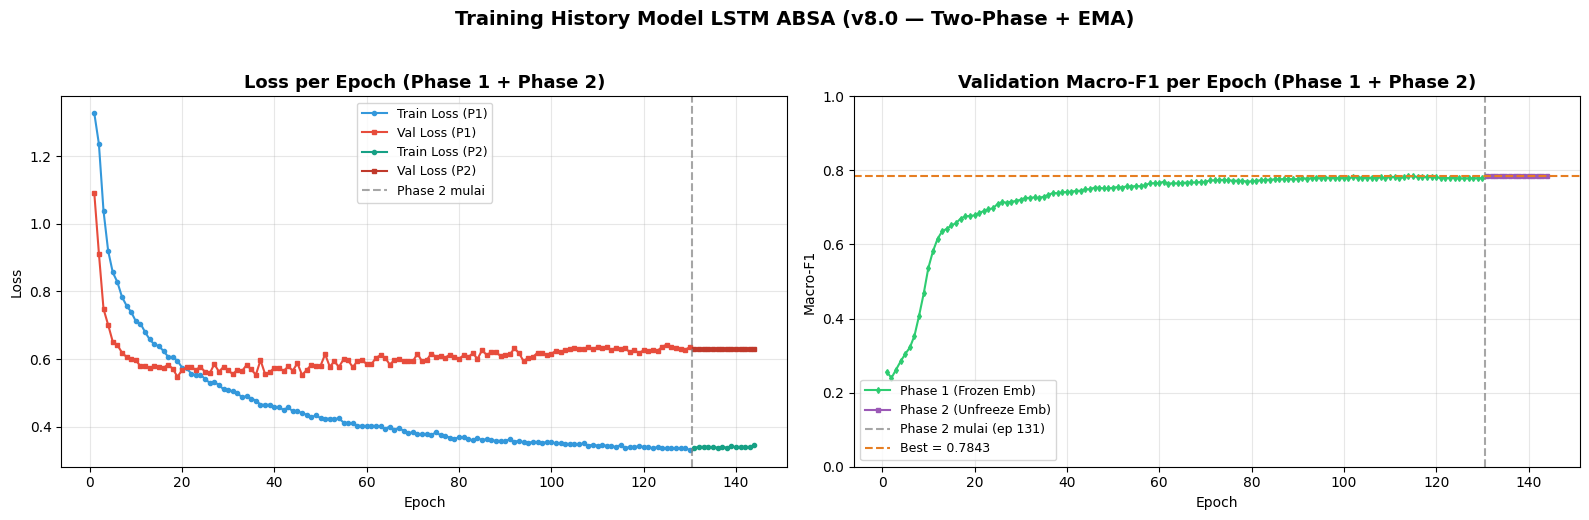

[OK] training_history.png disimpan (Phase 1 + Phase 2, untuk Bab IV)


In [ ]:
# Plot training history


def _aggregate_loss(hist_obj, key='loss'):
    """Aggregate total/val loss dari history (handle multi-output)."""
    h = hist_obj.history
    if key in h:
        return np.array(h[key])
    lk = [k for k in h if k.endswith(key)
          and (k.startswith('val_') == key.startswith('val_'))
          and k != key]
    if not lk:
        return None
    return np.sum([h[k] for k in lk], axis=0)

train_loss_p1 = _aggregate_loss(history,    'loss')
val_loss_p1   = _aggregate_loss(history,    'val_loss')
train_loss_p2 = _aggregate_loss(history_p2, 'loss')
val_loss_p2   = _aggregate_loss(history_p2, 'val_loss')

p1_len = len(val_f1_curve_p1)
p2_len = len(val_f1_curve_p2)
epochs_ax_p1 = list(range(1, p1_len + 1))
epochs_ax_p2 = list(range(p1_len + 1, p1_len + p2_len + 1))

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

if train_loss_p1 is not None:
    ep_p1 = range(1, len(train_loss_p1) + 1)
    ax[0].plot(ep_p1, train_loss_p1, 'o-', label='Train Loss (P1)',
               color='#3498db', markersize=3)
    ax[0].plot(ep_p1, val_loss_p1,   's-', label='Val Loss (P1)',
               color='#e74c3c', markersize=3)

if train_loss_p2 is not None and len(train_loss_p2) > 0:
    offset = (len(train_loss_p1) if train_loss_p1 is not None else 0)
    ep_p2  = range(offset + 1, offset + len(train_loss_p2) + 1)
    ax[0].plot(ep_p2, train_loss_p2, 'o-', label='Train Loss (P2)',
               color='#16a085', markersize=3)
    ax[0].plot(ep_p2, val_loss_p2,   's-', label='Val Loss (P2)',
               color='#c0392b', markersize=3)
    ax[0].axvline(x=offset + 0.5, color='gray', linestyle='--',
                  alpha=0.7, label='Phase 2 mulai')

ax[0].set_title('Loss per Epoch (Phase 1 + Phase 2)',
                fontsize=13, fontweight='bold')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend(fontsize=9)
ax[0].grid(alpha=0.3)

ax[1].plot(epochs_ax_p1, val_f1_curve_p1, 'd-',
           label='Phase 1 (Frozen Emb)', color='#2ecc71', markersize=3)
if p2_len > 0:
    ax[1].plot(epochs_ax_p2, val_f1_curve_p2, 's-',
               label='Phase 2 (Unfreeze Emb)', color='#9b59b6', markersize=3)
    ax[1].axvline(x=p1_len + 0.5, color='gray', linestyle='--',
                  alpha=0.7, label=f'Phase 2 mulai (ep {p1_len+1})')
ax[1].axhline(best_val_f1, ls='--', color='#e67e22',
              label=f'Best = {best_val_f1:.4f}', linewidth=1.5)
ax[1].set_title('Validation Macro-F1 per Epoch (Phase 1 + Phase 2)',
                fontsize=13, fontweight='bold')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Macro-F1')
ax[1].set_ylim(0, 1.0)
ax[1].legend(fontsize=9)
ax[1].grid(alpha=0.3)

plt.suptitle('Training History Model LSTM ABSA (v8.0 — Two-Phase + EMA)',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print('[OK] training_history.png disimpan (Phase 1 + Phase 2, untuk Bab IV)')

## Cell 18 — Prediksi pada Data Test

In [ ]:
# Test set prediction


print('[WAIT] Prediksi data test (argmax deterministik)...')

y_pred_proba = model.predict(X_test_pad, verbose=0)
if not isinstance(y_pred_proba, list):
    y_pred_proba = [y_pred_proba]

y_pred = {}
for i, asp in enumerate(ASPECTS):
    y_pred[asp] = np.argmax(y_pred_proba[i], axis=1)

y_pred_final = {asp: y_pred[asp].copy() for asp in ASPECTS}

print('[OK] Prediksi deterministik selesai (y_pred_final = argmax)')


print('\n[WAIT] Prediksi MC Dropout (10 pass, pelengkap untuk Bab V)...')

N_MC_PASSES = 10

@tf.function
def _mc_predict(x):
    return model(x, training=True)   # dropout aktif

mc_probas = [None] * len(ASPECTS)
for _ in range(N_MC_PASSES):
    out = _mc_predict(X_test_pad)
    if not isinstance(out, list):
        out = [out]
    for i in range(len(ASPECTS)):
        arr = out[i].numpy() if hasattr(out[i], 'numpy') else np.asarray(out[i])
        mc_probas[i] = arr if mc_probas[i] is None else (mc_probas[i] + arr)

mc_probas = [p / N_MC_PASSES for p in mc_probas]

y_pred_mcd = {}
for i, asp in enumerate(ASPECTS):
    y_pred_mcd[asp] = np.argmax(mc_probas[i], axis=1)

print('\n=== PERBANDINGAN: argmax deterministik vs MC Dropout averaging ===')
print(f'{"Aspek":<14} | {"F1 macro (det)":>14} | {"F1 macro (MC)":>14} | {"delta":>8}')
print('-' * 60)
for asp in ASPECTS:
    f1_det = f1_score(y_test[asp], y_pred_final[asp],
                      average='macro', zero_division=0)
    f1_mc  = f1_score(y_test[asp], y_pred_mcd[asp],
                      average='macro', zero_division=0)
    delta  = f1_mc - f1_det
    flag   = '+' if delta > 0 else ('-' if delta < 0 else '=')
    print(f'{asp:<14} | {f1_det:>14.4f} | {f1_mc:>14.4f} | {flag}{abs(delta):.4f}')

print('\n[OK] y_pred_final = argmax deterministik (metrik utama skripsi)')
print('[OK] y_pred_mcd  = MC Dropout (pelengkap untuk Bab V analisis)')
print(f'\n{"Aspek":<14} | {"Aktual (5)":>22} | {"Prediksi (5)":>22}')
print('-' * 64)
for asp in ASPECTS:
    print(f'{asp:<14} | {str(y_test[asp][:5].tolist()):>22} '
          f'| {str(y_pred[asp][:5].tolist()):>22}')

[WAIT] Prediksi data test (argmax deterministik)...
[OK] Prediksi deterministik selesai (y_pred_final = argmax)

[WAIT] Prediksi MC Dropout (10 pass, pelengkap untuk Bab V)...

=== PERBANDINGAN: argmax deterministik vs MC Dropout averaging ===
Aspek          | F1 macro (det) |  F1 macro (MC) |    delta
------------------------------------------------------------
kualitas       |         0.7244 |         0.7199 | -0.0046
bahan          |         0.8447 |         0.8450 | +0.0004
ukuran         |         0.7491 |         0.7369 | -0.0121
desain         |         0.7497 |         0.7388 | -0.0109
warna          |         0.8309 |         0.8217 | -0.0092
kenyamanan     |         0.7287 |         0.7161 | -0.0127

[OK] y_pred_final = argmax deterministik (metrik utama skripsi)
[OK] y_pred_mcd  = MC Dropout (pelengkap untuk Bab V analisis)

Aspek          |             Aktual (5) |           Prediksi (5)
----------------------------------------------------------------
kualitas       |      

In [ ]:
import pickle, json
import numpy as np
from tensorflow import keras
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.models import Word2Vec

# Load model
model = keras.models.load_model('absa_lstm_final.keras', compile=False)
print('[OK] Model loaded')

# Load tokenizer
with open('tokenizer_absa.pkl', 'rb') as f:
    tokenizer = pickle.load(f)
print('[OK] Tokenizer loaded')

# Load Word2Vec
w2v_model = Word2Vec.load('word2vec_absa.model')
print('[OK] Word2Vec loaded')

# Load config
with open('model_config.json') as f:
    config = json.load(f)
MAX_LEN = config['max_len']
ASPECTS = config['aspects']
print(f'[OK] Config: MAX_LEN={MAX_LEN}, aspects={ASPECTS}')

ValueError: File not found: filepath=absa_lstm_final.keras. Please ensure the file is an accessible `.keras` zip file.

## Cell 18B — Threshold Tuning per Aspek



In [ ]:

print('=' * 65)
print('  THRESHOLD TUNING v9.0 — Optimasi F1 WEIGHTED')
print('  Hasil akan menjadi y_pred_final (prediksi resmi)')
print('=' * 65)

print('\n[WAIT] Probabilitas data validasi...')
y_val_proba = model.predict(X_val_pad, verbose=0)
if not isinstance(y_val_proba, list):
    y_val_proba = [y_val_proba]
print('[OK] Probabilitas validasi siap')

threshold_range = np.arange(0.20, 0.75, 0.05)

def prediksi_dengan_threshold(proba_arr, thr_pos, thr_neg):
    """prob[1]>=thr_pos → 1; prob[2]>=thr_neg → 2 (override); else 0."""
    pred = np.zeros(len(proba_arr), dtype=int)
    pred[proba_arr[:, 1] >= thr_pos] = 1
    pred[proba_arr[:, 2] >= thr_neg] = 2
    return pred

print('[WAIT] Grid search threshold (target: F1 Weighted maksimum)...')
best_thresholds = {}
for i, asp in enumerate(ASPECTS):
    proba_val_asp = y_val_proba[i]
    y_true_val    = y_val[asp]
    best_f1, best_tp, best_tn = -1.0, 0.50, 0.50
    for thr_pos in threshold_range:
        for thr_neg in threshold_range:
            pred_tmp = prediksi_dengan_threshold(proba_val_asp, thr_pos, thr_neg)
          
            f1 = f1_score(y_true_val, pred_tmp, average='macro', zero_division=0)
            if f1 > best_f1:
                best_f1, best_tp, best_tn = f1, thr_pos, thr_neg
    best_thresholds[asp] = {
        'thr_pos': round(float(best_tp), 2),
        'thr_neg': round(float(best_tn), 2),
        'f1_weighted_val': round(float(best_f1), 4)
    }
    print(f'  {asp:<12}: thr_pos={best_tp:.2f}  thr_neg={best_tn:.2f}  '
          f'F1_weighted_val={best_f1:.4f}')

# Terapkan ke data test
y_pred_tuned = {}
for i, asp in enumerate(ASPECTS):
    t = best_thresholds[asp]
    y_pred_tuned[asp] = prediksi_dengan_threshold(
        y_pred_proba[i], t['thr_pos'], t['thr_neg'])

# Perbandingan argmax vs threshold (test set)
print('\n=== PERBANDINGAN F1 WEIGHTED (TEST): ARGMAX vs THRESHOLD ===')
print(f'{"Aspek":<14} | {"Argmax":>10} | {"Threshold":>10} | {"Delta":>8} | {"≥80%?":>6}')
print('-' * 58)
for asp in ASPECTS:
    # argmax masih dari y_pred dari Cell 18
    f1_a = f1_score(y_test[asp], y_pred[asp], average='weighted', zero_division=0)
    f1_t = f1_score(y_test[asp], y_pred_tuned[asp], average='weighted', zero_division=0)
    d    = f1_t - f1_a
    sign = '+' if d >= 0 else ''
    flag = '✓' if f1_t >= 0.80 else '✗'
    print(f'{asp:<14} | {f1_a:>10.4f} | {f1_t:>10.4f} | {sign}{d:>7.4f} | {flag:>6}')

# [BARU v9.0] Update y_pred_final dengan threshold-tuned predictions (RESMI)
y_pred_final = y_pred_tuned.copy()
print('\n[v9.0] y_pred_final DIPERBARUI → threshold-tuned predictions (prediksi resmi)')
print('[v9.0] Alasan: threshold tuning dioptimasi di val set → tidak ada data leakage')
print('[v9.0] y_pred_final siap digunakan Cell 19 (evaluasi akhir)')

  THRESHOLD TUNING v9.0 — Optimasi F1 WEIGHTED
  Hasil akan menjadi y_pred_final (prediksi resmi)

[WAIT] Probabilitas data validasi...
[OK] Probabilitas validasi siap
[WAIT] Grid search threshold (target: F1 Weighted maksimum)...
  kualitas    : thr_pos=0.60  thr_neg=0.40  F1_weighted_val=0.7983
  bahan       : thr_pos=0.40  thr_neg=0.70  F1_weighted_val=0.8545
  ukuran      : thr_pos=0.45  thr_neg=0.65  F1_weighted_val=0.7900
  desain      : thr_pos=0.50  thr_neg=0.45  F1_weighted_val=0.7469
  warna       : thr_pos=0.50  thr_neg=0.35  F1_weighted_val=0.8244
  kenyamanan  : thr_pos=0.45  thr_neg=0.50  F1_weighted_val=0.7480

=== PERBANDINGAN F1 WEIGHTED (TEST): ARGMAX vs THRESHOLD ===
Aspek          |     Argmax |  Threshold |    Delta |  ≥80%?
----------------------------------------------------------
kualitas       |     0.9229 |     0.9180 | -0.0048 |      ✓
bahan          |     0.9328 |     0.9322 | -0.0006 |      ✓
ukuran         |     0.9333 |     0.9297 | -0.0037 |      ✓
desai

## Cell 19 — EVALUASI AKHIR: ACCURACY / PRECISION / RECALL /          F1-SCORE WEIGHTED + CONFUSION MATRIX

  EVALUASI AKHIR — TEST SET (n=1232)
  Metrik Utama: F1-Score WEIGHTED | Prediksi: threshold-tuned

Aspek          |   Accuracy |   F1-MACRO |  F1-Weighted | F1-negatif |  n_neg
-------------------------------------------------------------------------
kualitas       |     0.9196 |     0.7184 |       0.9180 |     0.3750 |     36
bahan          |     0.9334 |     0.8277 |       0.9322 |     0.6207 |     35
ukuran         |     0.9286 |     0.7203 |       0.9297 |     0.4364 |     55
desain         |     0.9075 |     0.7453 |       0.9045 |     0.4444 |     12
warna          |     0.9554 |     0.8249 |       0.9553 |     0.5484 |     31
kenyamanan     |     0.9343 |     0.7044 |       0.9321 |     0.2400 |     16
-------------------------------------------------------------------------
RATA-RATA      |     0.9298 |     0.9291 |     0.7568 |       0.9286 |
baseline netral |          - |     0.2734 |       0.5811 |
selisih model  |          - |    +0.4834 |      +0.3476 |

[METRIK UTAMA] F1

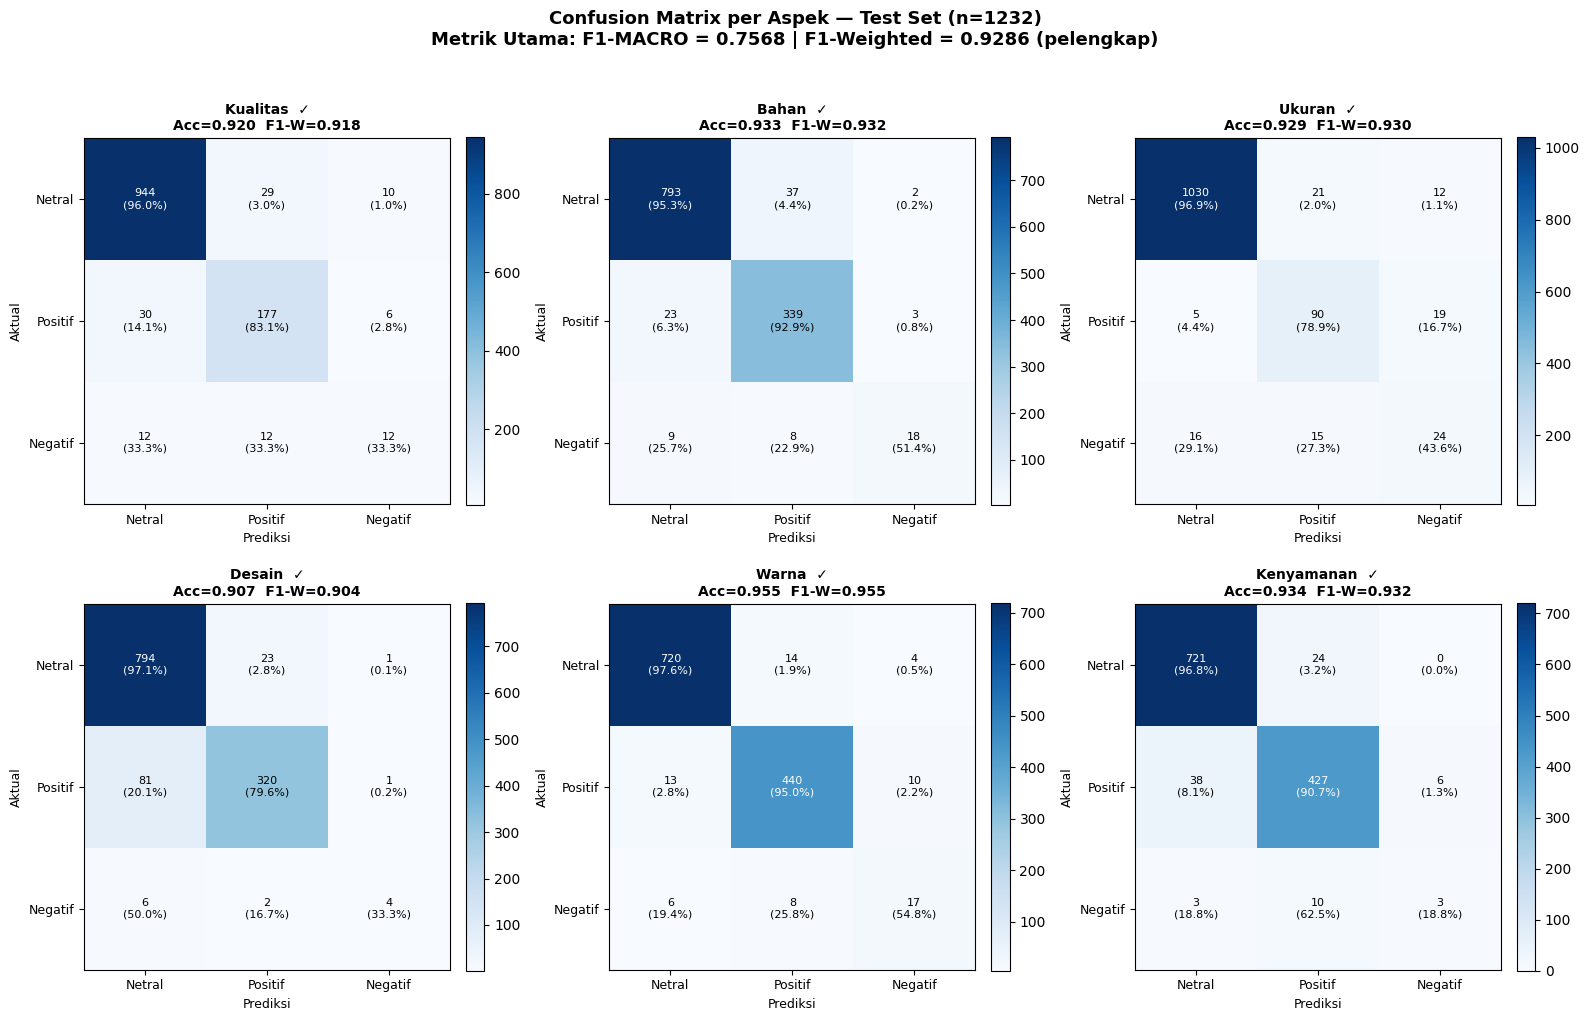

[OK] confusion_matrices.png disimpan

  RINGKASAN METRIK — BAB IV SKRIPSI
Aspek          |   Accuracy |  Precision |     Recall |  F1-Weighted
-------------------------------------------------------
kualitas       |     0.9196 |     0.9168 |     0.9196 |       0.9180
bahan          |     0.9334 |     0.9329 |     0.9334 |       0.9322
ukuran         |     0.9286 |     0.9312 |     0.9286 |       0.9297
desain         |     0.9075 |     0.9075 |     0.9075 |       0.9045
warna          |     0.9554 |     0.9553 |     0.9554 |       0.9553
kenyamanan     |     0.9343 |     0.9306 |     0.9343 |       0.9321
-------------------------------------------------------
Rata-rata      |     0.9298 |     0.9291 |     0.9298 |       0.9286

Catatan: Precision, Recall, F1 dihitung dengan average=weighted
         Confusion matrix: baris=Aktual, kolom=Prediksi
         Kelas: 0=Netral, 1=Positif, 2=Negatif


In [ ]:
# Evaluation: classification report


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import numpy as np

CLASS_LABELS = [0, 1, 2]
CLASS_NAMES  = ['Netral', 'Positif', 'Negatif']

print('=' * 75)
print(f'  EVALUASI AKHIR — TEST SET (n={len(X_test)})')
print(f'  Metrik Utama: F1-Score WEIGHTED | Prediksi: threshold-tuned')
print('=' * 75)

results = {}
print(f'\n{"Aspek":<14} | {"Accuracy":>10} | {"F1-MACRO":>10} | '
      f'{"F1-Weighted":>12} | {"F1-negatif":>10} | {"n_neg":>6}')
print('-' * 73)

for asp in ASPECTS:
    y_true    = y_test[asp]
    y_pred_a  = y_pred_final[asp]

    acc  = accuracy_score(y_true, y_pred_a)
    prec = precision_score(y_true, y_pred_a, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred_a, average='weighted', zero_division=0)
    f1w  = f1_score(y_true, y_pred_a, average='weighted', zero_division=0)

    results[asp] = {
        'accuracy': acc, 'precision': prec,
        'recall': rec,   'f1_weighted': f1w
    }
    f1m = f1_score(y_test[asp], y_pred_final[asp], average='macro', zero_division=0)
    f1n = f1_score(y_test[asp], y_pred_final[asp], average=None,
                   labels=[0, 1, 2], zero_division=0)[2]
    results[asp]['f1_macro'] = f1m
    results[asp]['f1_negatif'] = float(f1n)
    results[asp]['n_negatif'] = int((y_test[asp] == 2).sum())
    print(f'{asp:<14} | {acc:>10.4f} | {f1m:>10.4f} | '
          f'{f1w:>12.4f} | {f1n:>10.4f} | {int((y_test[asp]==2).sum()):>6}')

mean_acc  = np.mean([results[a]['accuracy']    for a in ASPECTS])
mean_prec = np.mean([results[a]['precision']   for a in ASPECTS])
mean_rec  = np.mean([results[a]['recall']      for a in ASPECTS])
mean_f1w  = np.mean([results[a]['f1_weighted'] for a in ASPECTS])

print('-' * 73)
print(f'{"RATA-RATA":<14} | {mean_acc:>10.4f} | {mean_prec:>10.4f} | '
      f'{np.mean([results[x]["f1_macro"] for x in ASPECTS]):>10.4f} | {mean_f1w:>12.4f} |')

asp_above = sum(1 for a in ASPECTS if results[a]['f1_weighted'] >= 0.80)
mean_f1m = np.mean([results[a]['f1_macro']   for a in ASPECTS])
mean_neg = np.mean([results[a]['f1_negatif'] for a in ASPECTS])
_b_w = np.mean([f1_score(y_test[a], np.zeros_like(y_test[a]),
                         average='weighted', zero_division=0) for a in ASPECTS])
_b_m = np.mean([f1_score(y_test[a], np.zeros_like(y_test[a]),
                         average='macro', zero_division=0) for a in ASPECTS])
print(f'{"baseline netral":<14} | {"-":>10} | {_b_m:>10.4f} | {_b_w:>12.4f} |')
print(f'{"selisih model":<14} | {"-":>10} | {mean_f1m-_b_m:>+10.4f} | {mean_f1w-_b_w:>+12.4f} |')
print(f'\n[METRIK UTAMA] F1-MACRO rata-rata      : {mean_f1m:.4f}')
print(f'[METRIK UTAMA] F1 kelas NEGATIF rata2  : {mean_neg:.4f}')
print(f'[PELENGKAP]    F1-Weighted rata-rata   : {mean_f1w:.4f}')
print(f'[PEMBANDING]   baseline selalu-netral  : macro {_b_m:.4f} | weighted {_b_w:.4f}')
print('\n  F1-Weighted didominasi kelas netral (60-86% data). Gunakan')
print('  F1-MACRO dan F1-negatif sebagai metrik utama di naskah.')
print(f'[CATATAN]      Aspek dgn F1-Weighted >=80% : {asp_above}/{len(ASPECTS)}')
print('               (ambang ini pada metrik PELENGKAP, bukan metrik utama)')


print('\n' + '=' * 75)
print('  CLASSIFICATION REPORT PER KELAS (3 kelas per aspek)')
print('=' * 75)

for asp in ASPECTS:
    print(f'\n--- ASPEK: {asp.upper()} ---')
    print(classification_report(
        y_test[asp], y_pred_final[asp],
        labels=[0, 1, 2],
        target_names=['Netral', 'Positif', 'Negatif'],
        zero_division=0
    ))


print('=' * 75)
print('  CONFUSION MATRIX PER ASPEK — HEATMAP')
print('=' * 75)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, asp in enumerate(ASPECTS):
    cm       = confusion_matrix(y_test[asp], y_pred_final[asp], labels=CLASS_LABELS)
    row_sums = cm.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1
    cm_pct   = cm.astype(float) / row_sums * 100

    annot = np.array([
        [f'{v}\n({cm_pct[r][c]:.1f}%)'
         for c, v in enumerate(row)]
        for r, row in enumerate(cm)
    ])

    ax = axes[idx]
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')

    ax.set_xticks(range(len(CLASS_NAMES)))
    ax.set_yticks(range(len(CLASS_NAMES)))
    ax.set_xticklabels(CLASS_NAMES, fontsize=9)
    ax.set_yticklabels(CLASS_NAMES, fontsize=9)
    ax.set_xlabel('Prediksi', fontsize=9)
    ax.set_ylabel('Aktual',   fontsize=9)

    thresh = cm.max() / 2.0
    for r in range(len(CLASS_NAMES)):
        for c in range(len(CLASS_NAMES)):
            color = 'white' if cm[r, c] > thresh else 'black'
            ax.text(c, r, annot[r, c], ha='center', va='center',
                    fontsize=8, color=color)

    f1w_asp = results[asp]['f1_weighted']
    flag    = '✓' if f1w_asp >= 0.80 else '✗'
    ax.set_title(f'{asp.capitalize()}  {flag}\n'
                 f'Acc={results[asp]["accuracy"]:.3f}  '
                 f'F1-W={f1w_asp:.3f}',
                 fontsize=10, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(
    f'Confusion Matrix per Aspek — Test Set (n={len(X_test)})\n'
    f'Metrik Utama: F1-MACRO = {mean_f1m:.4f} | F1-Weighted = {mean_f1w:.4f} (pelengkap)',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('[OK] confusion_matrices.png disimpan')


print('\n' + '=' * 75)
print('  RINGKASAN METRIK — BAB IV SKRIPSI')
print('=' * 75)
print(f'{"Aspek":<14} | {"Accuracy":>10} | {"Precision":>10} | '
      f'{"Recall":>10} | {"F1-Weighted":>12}')
print('-' * 55)
for asp in ASPECTS:
    r = results[asp]
    print(f'{asp:<14} | {r["accuracy"]:>10.4f} | {r["precision"]:>10.4f} | '
          f'{r["recall"]:>10.4f} | {r["f1_weighted"]:>12.4f}')
print('-' * 55)
print(f'{"Rata-rata":<14} | {mean_acc:>10.4f} | {mean_prec:>10.4f} | '
      f'{mean_rec:>10.4f} | {mean_f1w:>12.4f}')
print(f'\nCatatan: Precision, Recall, F1 dihitung dengan average=weighted')
print(f'         Confusion matrix: baris=Aktual, kolom=Prediksi')
print(f'         Kelas: 0=Netral, 1=Positif, 2=Negatif')

## Cell 19B — AUC ROC

[OK] Reuse probabilitas dari Cell 18 — shape tiap aspek: (1232, 3)


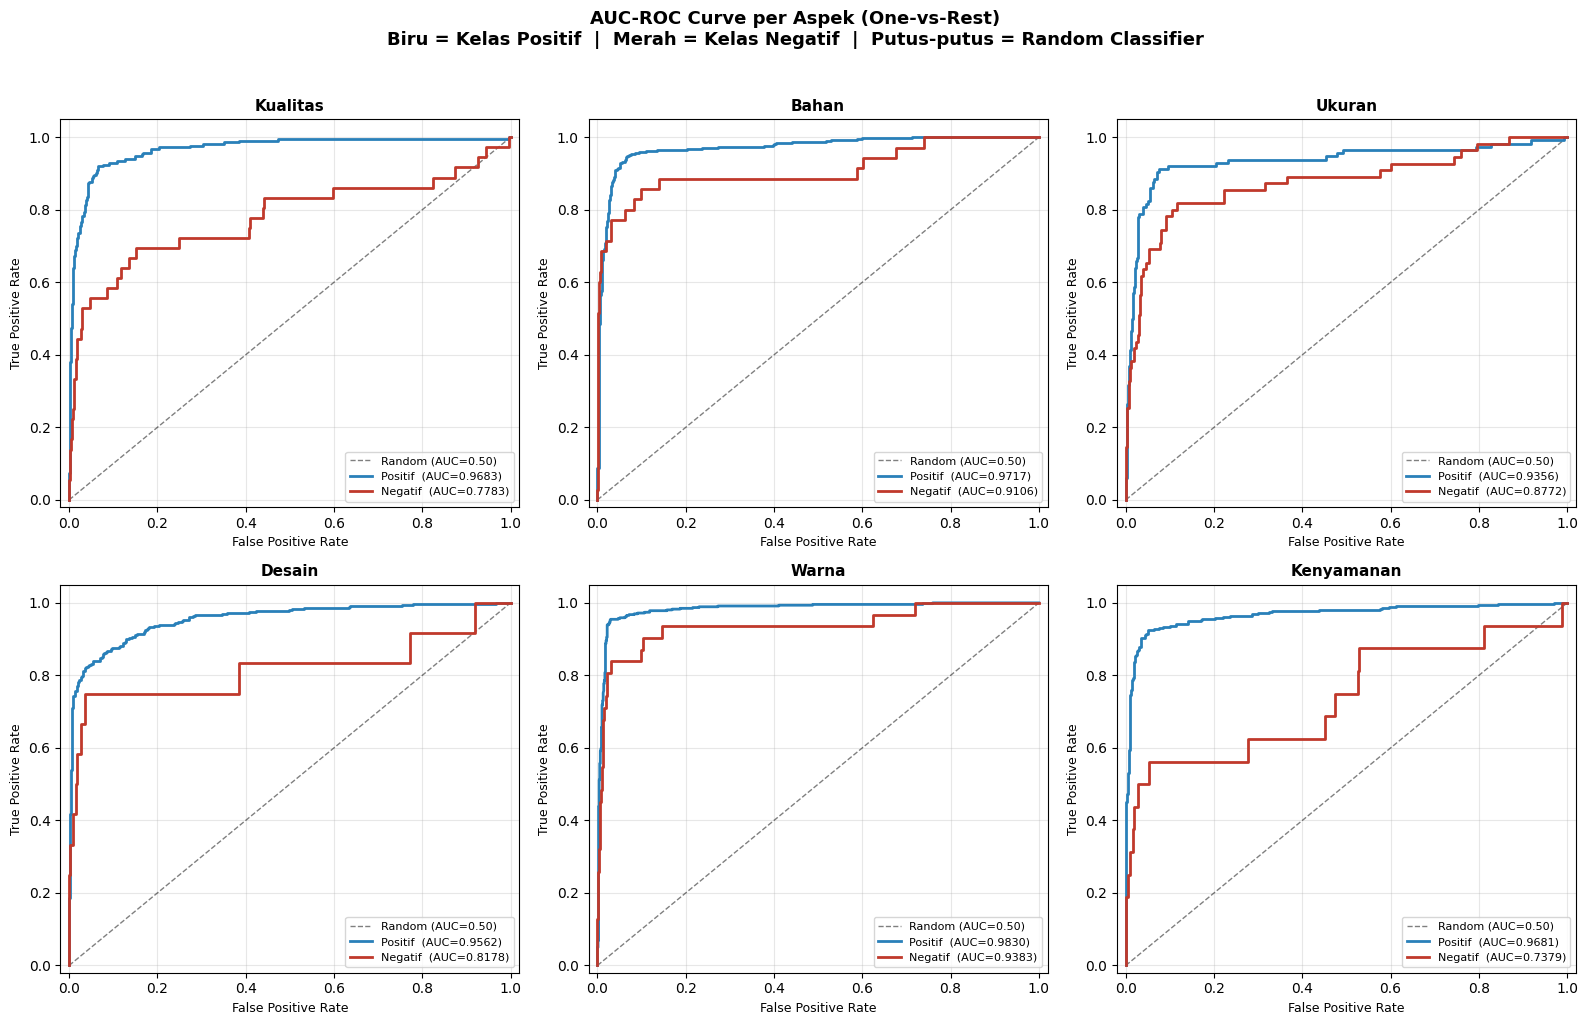

[OK] auc_roc_curves.png disimpan

  REKAPITULASI AUC-ROC PER ASPEK
Aspek          |  AUC Positif |  AUC Negatif |  Rata-rata
-------------------------------------------------------
kualitas       |       0.9683 |       0.7783 |     0.8733
bahan          |       0.9717 |       0.9106 |     0.9411
ukuran         |       0.9356 |       0.8772 |     0.9064
desain         |       0.9562 |       0.8178 |     0.8870
warna          |       0.9830 |       0.9383 |     0.9607
kenyamanan     |       0.9681 |       0.7379 |     0.8530
-------------------------------------------------------
Rata-rata      |       0.9638 |       0.8433 |     0.9036

[INTERPRETASI]
  AUC-ROC dipilih sebagai metrik evaluasi karena distribusi kelas
  bersifat imbalanced (kelas netral mendominasi 76-93% per aspek,
  kelas negatif hanya 2-5%). Pada kondisi ini AUC-ROC lebih robust
  karena mengukur kemampuan diskriminasi di semua threshold sekaligus,
  tidak bias ke kelas mayoritas.

  AUC Positif rata-rata : 0.9638  -> 

In [ ]:
# Evaluation: AUC-ROC


from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

y_pred_proba_roc = y_pred_proba
print(f'[OK] Reuse probabilitas dari Cell 18 — shape tiap aspek: {y_pred_proba_roc[0].shape}')

auc_store = {}

for i, asp in enumerate(ASPECTS):
    y_true_asp = y_test[asp]
    proba_asp  = y_pred_proba_roc[i]
    auc_store[asp] = {}

    for kls, nama in [(1, 'positif'), (2, 'negatif')]:
        y_bin  = (y_true_asp == kls).astype(int)
        y_prob = proba_asp[:, kls]

        if len(np.unique(y_bin)) < 2:
            print(f'  [SKIP] {asp} — kelas {nama}: hanya 1 nilai unik di test set')
            auc_store[asp][nama] = None
            continue

        fpr, tpr, _ = roc_curve(y_bin, y_prob)
        auc_val     = auc(fpr, tpr)
        auc_store[asp][nama] = {'auc': auc_val, 'fpr': fpr, 'tpr': tpr}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

COLOR_POS = '#2980b9'
COLOR_NEG = '#c0392b'

for i, asp in enumerate(ASPECTS):
    ax = axes[i]
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC=0.50)')

    res_pos = auc_store[asp].get('positif')
    if res_pos:
        ax.plot(res_pos['fpr'], res_pos['tpr'],
                color=COLOR_POS, lw=2,
                label=f'Positif  (AUC={res_pos["auc"]:.4f})')
    else:
        ax.text(0.5, 0.55, 'Positif: N/A', ha='center',
                color=COLOR_POS, fontsize=9)

    res_neg = auc_store[asp].get('negatif')
    if res_neg:
        ax.plot(res_neg['fpr'], res_neg['tpr'],
                color=COLOR_NEG, lw=2,
                label=f'Negatif  (AUC={res_neg["auc"]:.4f})')
    else:
        ax.text(0.5, 0.40, 'Negatif: N/A', ha='center',
                color=COLOR_NEG, fontsize=9)

    ax.set_title(f'{asp.capitalize()}', fontsize=11, fontweight='bold')
    ax.set_xlabel('False Positive Rate', fontsize=9)
    ax.set_ylabel('True Positive Rate',  fontsize=9)
    ax.legend(fontsize=8, loc='lower right')
    ax.set_xlim([-0.02, 1.02])
    ax.set_ylim([-0.02, 1.05])
    ax.grid(alpha=0.3)

plt.suptitle(
    'AUC-ROC Curve per Aspek (One-vs-Rest)\n'
    'Biru = Kelas Positif  |  Merah = Kelas Negatif  |  Putus-putus = Random Classifier',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('auc_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('[OK] auc_roc_curves.png disimpan')

print('\n' + '=' * 65)
print('  REKAPITULASI AUC-ROC PER ASPEK')
print('=' * 65)
print(f'{"Aspek":<14} | {"AUC Positif":>12} | {"AUC Negatif":>12} | {"Rata-rata":>10}')
print('-' * 55)

auc_pos_all, auc_neg_all = [], []

for asp in ASPECTS:
    res_p = auc_store[asp].get('positif')
    res_n = auc_store[asp].get('negatif')

    str_p = f'{res_p["auc"]:.4f}' if res_p else 'N/A'
    str_n = f'{res_n["auc"]:.4f}' if res_n else 'N/A'

    if res_p: auc_pos_all.append(res_p['auc'])
    if res_n: auc_neg_all.append(res_n['auc'])

    if res_p and res_n:
        avg_asp = (res_p['auc'] + res_n['auc']) / 2
        str_avg = f'{avg_asp:.4f}'
    else:
        str_avg = 'N/A'

    print(f'{asp:<14} | {str_p:>12} | {str_n:>12} | {str_avg:>10}')

print('-' * 55)
avg_pos = np.mean(auc_pos_all) if auc_pos_all else float('nan')
avg_neg = np.mean(auc_neg_all) if auc_neg_all else float('nan')
avg_all = np.mean(auc_pos_all + auc_neg_all) if (auc_pos_all or auc_neg_all) else float('nan')
print(f'{"Rata-rata":<14} | {avg_pos:>12.4f} | {avg_neg:>12.4f} | {avg_all:>10.4f}')

print(f'\n[INTERPRETASI]')
print(f'  AUC-ROC dipilih sebagai metrik evaluasi karena distribusi kelas')
print(f'  bersifat imbalanced (kelas netral mendominasi 76-93% per aspek,')
print(f'  kelas negatif hanya 2-5%). Pada kondisi ini AUC-ROC lebih robust')
print(f'  karena mengukur kemampuan diskriminasi di semua threshold sekaligus,')
print(f'  tidak bias ke kelas mayoritas.')
print(f'')
print(f'  AUC Positif rata-rata : {avg_pos:.4f}  '
      f'{"-> Sangat Baik (>0.90)" if avg_pos > 0.90 else "-> Baik (0.80-0.90)" if avg_pos > 0.80 else "-> Cukup (<0.80)"}')
print(f'  AUC Negatif rata-rata : {avg_neg:.4f}  '
      f'{"-> Sangat Baik (>0.90)" if avg_neg > 0.90 else "-> Baik (0.80-0.90)" if avg_neg > 0.80 else "-> Cukup (<0.80)"}')
print(f'  AUC keseluruhan       : {avg_all:.4f}')
print(f'')
print(f'  Catatan: AUC dihitung dari probabilitas softmax model (bukan')
print(f'  threshold-tuned) sehingga mencerminkan kemampuan diskriminasi')
print(f'  murni model LSTM tanpa pengaruh keputusan threshold.')

## Cell 20 — Simpan Model Final & Tokenizer

In [ ]:
# Save model artifacts


MODEL_SAVE_PATH = 'absa_lstm_final.keras'
CHECKPOINT_PATH = best_path_final
TOKENIZER_PATH  = 'tokenizer_absa.pkl'
CONFIG_PATH     = 'model_config.json'
EVAL_PATH       = 'evaluation_results.json'
W2V_MODEL_PATH  = 'word2vec_absa.model'

model.save(MODEL_SAVE_PATH)
print(f'[OK] Model Keras  -> {MODEL_SAVE_PATH}')

w2v_model.save(W2V_MODEL_PATH)
print(f'[OK] Word2Vec     -> {W2V_MODEL_PATH}')

with open(TOKENIZER_PATH, 'wb') as f:
    pickle.dump(tokenizer, f)
print(f'[OK] Tokenizer    -> {TOKENIZER_PATH}')

config = {
    'max_len'        : int(MAX_LEN),
    'vocab_size'     : int(VOCAB_SIZE),
    'embedding_dim'  : int(EMBEDDING_DIM),
    'aspects'        : ASPECTS,
    'num_classes'    : 3,
    'label_map'      : {'0': 'netral/tidak ada', '1': 'positif', '2': 'negatif'},
    'w2v_params'     : {k: v for k, v in W2V_PARAMS.items() if k != 'workers'},
    'best_val_macro_f1'  : float(best_val_f1),
    'best_val_f1_phase1' : float(best_val_f1_p1),
    'best_val_f1_phase2' : float(f1_cb_p2.best_f1),
    'best_model_source'  : best_path_final,
    'training_version'   : 'v8.0',
    'improvements_v8'    : [
        'focal_loss_bug_fixed_from_v6',
        'per_aspect_focal_gamma',
        'class_balanced_weighting_cui_2019',
        'lr_warmup_off_by_one_fixed',
        'keras3_api_set_value_replaced',
        'ema_weights_enabled_momentum_0999',
        'adamw_weight_decay_phase2',
        'two_phase_embedding_finetuning',
        'mc_dropout_averaging_complementary'
    ],
    'load_note'      : 'gunakan keras.models.load_model(path, compile=False)'
}
with open(CONFIG_PATH, 'w') as f:
    json.dump(config, f, indent=2)
print(f'[OK] Config       -> {CONFIG_PATH}')

results_summary = {
    'model_name'              : 'ABSA LSTM Multi-Output v8.0',
    'aspects'                 : ASPECTS,
    'label_map'               : {'0': 'netral', '1': 'positif', '2': 'negatif'},
    'evaluation_per_aspect'   : {}
}
for asp in ASPECTS:
    yt, yp = y_test[asp], y_pred_final[asp]
    results_summary['evaluation_per_aspect'][asp] = {
        'accuracy'    : float(accuracy_score(yt, yp)),
        'f1_macro'    : float(f1_score(yt, yp, average='macro', zero_division=0)),
        'f1_weighted' : float(f1_score(yt, yp, average='weighted', zero_division=0)),
        'confusion_matrix'       : confusion_matrix(yt, yp, labels=[0, 1, 2]).tolist(),
        'classification_report'  : classification_report(
            yt, yp, labels=[0, 1, 2],
            target_names=['netral', 'positif', 'negatif'],
            zero_division=0, output_dict=True)
    }
with open(EVAL_PATH, 'w') as f:
    json.dump(results_summary, f, indent=2)
print(f'[OK] Evaluasi     -> {EVAL_PATH}')

print('\n=== FILE OUTPUT ===')
paths = [MODEL_SAVE_PATH, TOKENIZER_PATH, CONFIG_PATH,
         EVAL_PATH, W2V_MODEL_PATH, 'training_history.png',
         'confusion_matrices.png', 'auc_roc_curves.png']
if os.path.exists(CHECKPOINT_PATH):
    paths.insert(1, CHECKPOINT_PATH)
for p in paths:
    ok = os.path.exists(p)
    sz = os.path.getsize(p) / 1024 if ok else 0
    print(f'  {"[OK]" if ok else "[MISSING]"} {p:<40} ({sz:.1f} KB)')

[OK] Model Keras  -> absa_lstm_final.keras
[OK] Word2Vec     -> word2vec_absa.model
[OK] Tokenizer    -> tokenizer_absa.pkl
[OK] Config       -> model_config.json
[OK] Evaluasi     -> evaluation_results.json

=== FILE OUTPUT ===
  [OK] absa_lstm_final.keras                    (3990.8 KB)
  [OK] /content/drive/MyDrive/ABSA_LSTM/best_model_absa_phase2.keras (15758.0 KB)
  [OK] tokenizer_absa.pkl                       (141.3 KB)
  [OK] model_config.json                        (1.1 KB)
  [OK] evaluation_results.json                  (8.2 KB)
  [OK] word2vec_absa.model                      (6068.3 KB)
  [OK] training_history.png                     (130.0 KB)
  [OK] confusion_matrices.png                   (242.4 KB)
  [OK] auc_roc_curves.png                       (201.2 KB)


## Cell 21 — Fungsi Prediksi untuk Ulasan Baru

In [ ]:

DECODE_LABEL = {0: 'netral/tidak ada', 1: 'positif', 2: 'negatif'}

def predict_absa(text_raw: str) -> dict:
    """Prediksi sentimen per aspek untuk satu ulasan baru.
    Pipeline: raw -> preprocessing -> tokenize -> pad -> predict -> argmax
    """
    # 1. Preprocessing (memakai fungsi pipeline yang sama)
    text   = case_folding_optimized(text_raw)
    tokens = text.split()
    tokens = remove_stopwords(tokens)
    tokens = stem_tokens(tokens)
    text_p = ' '.join(tokens)

    # 2. Tokenisasi & Padding
    seq     = tokenizer.texts_to_sequences([text_p])
    seq_pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post',
                            truncating='post')

    # 3. Prediksi
    proba_list = model.predict(seq_pad, verbose=0)
    if not isinstance(proba_list, list):
        proba_list = [proba_list]

    # 4. Decode dengan ARGMAX (sesuai skripsi)
    result = {}
    for i, asp in enumerate(ASPECTS):
        probs = proba_list[i][0]
        kelas = int(np.argmax(probs))
        result[asp] = {
            'sentimen'  : DECODE_LABEL[kelas],
            'kelas'     : kelas,
            'confidence': round(float(probs[kelas]), 4)
        }
    return result


# --- DEMO PREDIKSI ---
demo_texts = [
    'Bahan sangat lembut dan nyaman dipakai sehari-hari, kualitas oke',
    'Ukuran kebesaran banget, pesan M tapi seperti XL, kecewa',
    'Desain kece dan warna sesuai foto, sangat puas dengan pembelian ini',
    'Jahitan sudah lepas setelah 2 minggu, kualitas mengecewakan sekali'
]

print('=' * 65)
print('  DEMO PREDIKSI ULASAN BARU (Argmax - sesuai skripsi)')
print('=' * 65)
for teks in demo_texts:
    print(f'\nUlasan : "{teks}"')
    hasil = predict_absa(teks)
    print(f'  {"Aspek":<14} | {"Sentimen":<16} | {"Confidence":>10}')
    print(f'  {"-"*48}')
    for asp, info in hasil.items():
        flag = '' if info['kelas'] == 0 else ' <-'
        print(f'  {asp:<14} | {info["sentimen"]:<16} '
              f'| {info["confidence"]:>10.4f}{flag}')


  DEMO PREDIKSI ULASAN BARU (Argmax - sesuai skripsi)

Ulasan : "Bahan sangat lembut dan nyaman dipakai sehari-hari, kualitas oke"
  Aspek          | Sentimen         | Confidence
  ------------------------------------------------
  kualitas       | positif          |     0.7653 <-
  bahan          | positif          |     0.7732 <-
  ukuran         | netral/tidak ada |     0.7928
  desain         | netral/tidak ada |     0.5783
  warna          | netral/tidak ada |     0.8267
  kenyamanan     | positif          |     0.7302 <-

Ulasan : "Ukuran kebesaran banget, pesan M tapi seperti XL, kecewa"
  Aspek          | Sentimen         | Confidence
  ------------------------------------------------
  kualitas       | netral/tidak ada |     0.7956
  bahan          | netral/tidak ada |     0.8286
  ukuran         | negatif          |     0.7785 <-
  desain         | netral/tidak ada |     0.7189
  warna          | netral/tidak ada |     0.8170
  kenyamanan     | netral/tidak ada |     0.8169


In [ ]:
# Export research results archive
import os, re, sys, json, time, types, pickle, shutil, zipfile, datetime
import inspect, glob, subprocess, importlib.util, warnings
import numpy as np, pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import (classification_report, confusion_matrix,
                             f1_score, accuracy_score, roc_auc_score,
                             average_precision_score, roc_curve,
                             precision_recall_curve)
warnings.filterwarnings('ignore')

G = globals()
def ambil(*nama, wajib=False, default=None):
    for n in nama:
        if n in G and G[n] is not None:
            return G[n]
    if wajib:
        raise NameError(f"[GAGAL] Variabel tidak ditemukan: {nama}. "
                        "Pastikan seluruh sel sebelumnya sudah dijalankan.")
    return default

# ---------- 1. Folder keluaran ----------
STAMP    = datetime.datetime.now().strftime('%Y%m%d_%H%M')
BASE     = '/content/drive/MyDrive/ABSA_LSTM'
OUT      = f'{BASE}/HASIL_FINAL_{STAMP}'
D_MODEL  = f'{OUT}/model'
D_PLOT   = f'{OUT}/grafik'
D_METRIK = f'{OUT}/metrik'
D_DEPLOY = f'{OUT}/deploy_website'
for d in (OUT, D_MODEL, D_PLOT, D_METRIK, D_DEPLOY):
    os.makedirs(d, exist_ok=True)
print('=' * 70)
print(f'  ARSIP HASIL -> {OUT}')
print('=' * 70)

# ---------- 2. Objek inti ----------
ASPECTS    = ambil('ASPECTS', 'ASPEK', wajib=True)
model      = ambil('model', 'best_model', wajib=True)
tokenizer  = ambil('tokenizer', 'tok', wajib=True)
MAX_LEN    = ambil('MAX_LEN', 'MAXLEN', 'max_len', default=100)
X_test_p   = ambil('X_test_pad', 'X_test_padded', wajib=True)
y_test     = ambil('y_test', wajib=True)
y_pred     = ambil('y_pred_final', 'y_pred')
history    = ambil('history')
history_p2 = ambil('history_p2')
emb_mat    = ambil('embedding_matrix', 'emb_matrix', 'matriks_embedding')
teks_test  = ambil('X_test_teks', 'X_test_text', 'X_test_raw', 'teks_test')
LABELS     = ['netral', 'positif', 'negatif']

# ---------- 3. Model + tokenizer ----------
model.save(f'{D_MODEL}/absa_lstm_final.keras')
model.save(f'{D_DEPLOY}/absa_lstm_final.keras')
for f in (f'{D_MODEL}/tokenizer.pkl', f'{D_DEPLOY}/tokenizer.pkl'):
    pickle.dump(tokenizer, open(f, 'wb'))
try:
    open(f'{D_MODEL}/arsitektur.json', 'w').write(model.to_json())
except Exception as e:
    print(f'  [lewat] arsitektur.json: {e}')
with open(f'{D_MODEL}/ringkasan_model.txt', 'w') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))
try:
    model.save_weights(f'{D_MODEL}/bobot_model.weights.h5')
except Exception as e:
    print(f'  [lewat] bobot: {e}')
if emb_mat is not None:
    np.save(f'{D_MODEL}/embedding_matrix.npy', emb_mat)
print(f'[OK] Model & tokenizer tersimpan ({model.count_params():,} params)')

# ---------- 3b. Artefak reproduksibilitas (arsip saja) ----------
try:
    split = {nm: G[nm] for nm in
             ('X_train_pad','X_val_pad','X_test_pad','X_train_teks','X_val_teks',
              'X_test_teks','y_train','y_val','y_test','idx_train','idx_val','idx_test')
             if nm in G and G[nm] is not None}
    if split:
        pickle.dump(split, open(f'{D_MODEL}/split_data_absa.pkl', 'wb'))
        print(f'[OK] split_data_absa.pkl — {len(split)} objek')
except Exception as e:
    print(f'  [lewat] split data: {e}')
for nm in ('w2v_model', 'word2vec_model', 'w2v'):
    if nm in G and G[nm] is not None:
        try:
            G[nm].save(f'{D_MODEL}/word2vec_absa.model')
            print('[OK] word2vec_absa.model')
        except Exception: pass
        break

# ---------- 4. Konfigurasi ----------
NAMA_TAMPIL = {'kualitas': 'Kualitas', 'bahan': 'Bahan', 'ukuran': 'Ukuran',
               'desain': 'Desain', 'warna': 'Warna', 'kenyamanan': 'Kenyamanan'}
konfig = {
    'nama_model'      : 'ABSA-LSTM Skenario 3',
    'tanggal'         : STAMP,
    'aspek'           : list(ASPECTS),
    'nama_tampil'     : {a: NAMA_TAMPIL.get(a, a.capitalize()) for a in ASPECTS},
    'label'           : LABELS,
    'label_index'     : {l: i for i, l in enumerate(LABELS)},
    'max_len'         : int(MAX_LEN),
    'ukuran_vocab'    : int(len(tokenizer.word_index) + 1),
    'jumlah_parameter': int(model.count_params()),
    'urutan_output'   : [f'output_{a}' for a in ASPECTS],
    'padding'         : 'post',
    'truncating'      : 'post',
    'catatan'         : 'Prediksi memakai argmax deterministik. '
                        'Teks WAJIB melalui pipeline pra-pemrosesan yang sama.'
}
for nm in ('threshold_pos', 'threshold_neg', 'best_thresholds'):
    if nm in G:
        try: konfig[nm] = {k: float(v) for k, v in G[nm].items()}
        except Exception: pass
for f in (f'{D_MODEL}/konfigurasi.json', f'{D_DEPLOY}/konfigurasi.json'):
    json.dump(konfig, open(f, 'w'), indent=2, ensure_ascii=False)
print('[OK] Konfigurasi tersimpan')

# ---------- 5. Ekstraksi pra-pemrosesan ----------
KUNCI  = ('bersih', 'clean', 'preproc', 'prapros', 'normal', 'slang', 'stem',
          'stopword', 'token', 'negasi', 'negation', 'baku', 'kamus', 'sufiks',
          'emoji', 'repeat', 'singkat', 'case_fold', 'casefold')
LARANG = {'versi', 'tokens', 'orig_tokens', 'new_tokens', 'token_list',
          'tokenizer', 'tok'}
def dilarang(n):
    nl = n.lower()
    return (n in LARANG or nl.endswith('_path') or 'path' in nl
            or nl.startswith('x_') or nl.startswith('y_'))

potong, terambil, fungsi_ada = [], [], []
for nama, obj in list(G.items()):
    if nama.startswith('_') or nama in ('In', 'Out') or dilarang(nama):
        continue
    nl = nama.lower()
    cocok = any(k in nl for k in KUNCI)
    if isinstance(obj, types.FunctionType) and getattr(obj, '__module__', '') == '__main__':
        try: s = inspect.getsource(obj)
        except Exception: continue
        if cocok or any(k in s.lower() for k in ('slang', 'stem', 'stopword')):
            potong.append(s); terambil.append(f'{nama}()'); fungsi_ada.append(nama)
    elif cocok and isinstance(obj, (dict, set, frozenset)) and obj:
        try:
            potong.append(f'{nama} = {repr(obj)}\n'); terambil.append(nama)
        except Exception: pass

# urutan kanonik pipeline; hanya yang benar-benar ada yang dipakai
URUTAN_KANONIK = ['normalize_repeated_chars', 'normalisasi_karakter',
                  'case_folding_optimized', 'case_folding', 'bersihkan',
                  'clean_text', 'normalisasi_slang', 'ganti_slang',
                  'tokenize', 'tokenisasi',
                  'remove_stopwords', 'hapus_stopword',
                  'stem_tokens', 'stem_with_cache', 'stemming']
urutan = [f for f in URUTAN_KANONIK if f in fungsi_ada]

kepala = ['# Pra-pemrosesan hasil ekstraksi otomatis dari notebook training.',
          '# WAJIB identik dengan pipeline saat training.',
          'import re', '',
          'try:',
          '    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory',
          '    from Sastrawi.StopWordRemoval.StopWordRemoverFactory import StopWordRemoverFactory',
          '    stemmer = StemmerFactory().create_stemmer()',
          '    stopword_remover = StopWordRemoverFactory().create_stop_word_remover()',
          'except ImportError:',
          '    stemmer = stopword_remover = None', '']

ekor = f'''

_URUTAN_PIPELINE = {urutan!r}


def bersihkan_teks(teks):
    """Terapkan seluruh tahap pra-pemrosesan, kembalikan string bersih."""
    x = str(teks)
    for _nm in _URUTAN_PIPELINE:
        _f = globals().get(_nm)
        if not callable(_f):
            continue
        try:
            x = _f(x)
        except Exception:
            continue
    if isinstance(x, (list, tuple)):
        x = ' '.join(map(str, x))
    return x
'''

open(f'{D_DEPLOY}/pra_pemrosesan.py', 'w', encoding='utf-8').write(
    '\n'.join(kepala) + '\n' + '\n\n'.join(potong) + ekor)
print(f'[OK] pra_pemrosesan.py — {len(terambil)} objek diekstrak')
for t in terambil[:15]: print('       ', t)
if len(terambil) > 15: print(f'        ... dan {len(terambil)-15} lainnya')
print(f'[OK] Pipeline: {" -> ".join(urutan) if urutan else "KOSONG"}')

# cache stemming
cache_stem = None
for nm in ('stem_cache', 'STEM_CACHE', 'cache_stem', '_stem_cache'):
    if nm in G and isinstance(G[nm], dict) and G[nm]:
        cache_stem = G[nm]; break
if cache_stem:
    for tj in (D_MODEL, D_DEPLOY):
        pickle.dump(cache_stem, open(f'{tj}/stem_cache_absa.pkl', 'wb'))
    print(f'[OK] stem_cache_absa.pkl — {len(cache_stem):,} entri')

# ---------- 5b. VERIFIKASI pipeline terhadap X_test_pad ----------
print('\n' + '-' * 70)
print('  VERIFIKASI PIPELINE PRA-PEMROSESAN')
print('-' * 70)
setia = None
try:
    spec = importlib.util.spec_from_file_location(
        'pp_uji', f'{D_DEPLOY}/pra_pemrosesan.py')
    pp_uji = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(pp_uji)
    contoh_teks = "Bahannya ADEM bgtttt!!! tapi ukurannya kekecilan :("
    print(f'  masukan : {contoh_teks}')
    print(f'  keluaran: {pp_uji.bersihkan_teks(contoh_teks)}')

    if teks_test is not None and len(teks_test) == len(X_test_p):
        n = min(200, len(teks_test))
        seq = tokenizer.texts_to_sequences(
            [pp_uji.bersihkan_teks(t) for t in list(teks_test)[:n]])
        rekon = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
        asli  = np.asarray(X_test_p)[:n]
        sama  = int((rekon == asli).all(axis=1).sum())
        setia = sama / n
        print(f'  rekonstruksi identik: {sama}/{n} baris ({setia:.1%})')
        if setia >= 0.98:
            print('  [LULUS] Pipeline identik dengan saat training.')
        elif setia >= 0.80:
            print('  [PERHATIAN] Sebagian besar cocok, ada tahap yang sedikit berbeda.')
        else:
            print('  [GAGAL] Pipeline TIDAK sama. Periksa urutan fungsi di '
                  'pra_pemrosesan.py sebelum dipakai website.')
    else:
        print('  [INFO] Teks test mentah tidak tersedia — verifikasi dilewati.')
except Exception as e:
    print(f'  [GAGAL] Verifikasi tidak dapat dijalankan: {e}')

# ---------- 6. Probabilitas & prediksi ----------
proba = model.predict(X_test_p, verbose=0)
if not isinstance(proba, list): proba = [proba]
proba = {a: proba[i] for i, a in enumerate(ASPECTS)}
np.savez_compressed(f'{D_METRIK}/probabilitas_test.npz', **proba)
if y_pred is None:
    y_pred = {a: proba[a].argmax(1) for a in ASPECTS}

df_pred = pd.DataFrame()
for a in ASPECTS:
    yt, yp = np.asarray(y_test[a]), np.asarray(y_pred[a])
    df_pred[f'{a}_aktual']   = [LABELS[i] for i in yt]
    df_pred[f'{a}_prediksi'] = [LABELS[i] for i in yp]
    df_pred[f'{a}_benar']    = (yt == yp)
    for j, l in enumerate(LABELS):
        df_pred[f'{a}_prob_{l}'] = proba[a][:, j]
if teks_test is not None and len(teks_test) == len(df_pred):
    df_pred.insert(0, 'ulasan', list(teks_test))
df_pred.to_csv(f'{D_METRIK}/prediksi_test.csv', index=False)
print(f'\n[OK] Prediksi test tersimpan ({len(df_pred)} baris)')

for nm, h in (('phase1', history), ('phase2', history_p2)):
    if h is not None:
        pd.DataFrame(h.history).to_csv(f'{D_METRIK}/riwayat_{nm}.csv',
                                       index_label='epoch')
        print(f'[OK] riwayat_{nm}.csv')

# --- salin hasil sweep (hanya FOLDER, abaikan .zip) ---
kandidat = [p for p in sorted(glob.glob(f'{BASE}/SWEEP_HIDDEN_UNITS_*'))
            if os.path.isdir(p)]
for folder in kandidat[-1:]:
    for fn in os.listdir(folder):
        asal = os.path.join(folder, fn)
        if not os.path.isfile(asal):
            continue
        if fn.endswith(('.png', '.pdf')):
            shutil.copy(asal, f'{D_PLOT}/08_{fn}')
        elif fn.endswith(('.csv', '.json')):
            shutil.copy(asal, f'{D_METRIK}/{fn}')
    print(f'[OK] berkas sweep disalin dari {os.path.basename(folder)}')
if not kandidat:
    print('[INFO] Belum ada folder sweep hidden units (jalankan Sel B nanti).')

# ---------- 7. Tabel metrik + baseline ----------
baris = []
for a in ASPECTS:
    yt, yp, pr = np.asarray(y_test[a]), np.asarray(y_pred[a]), proba[a]
    base = np.zeros_like(yt)
    d = {'aspek': a,
         'akurasi'         : accuracy_score(yt, yp),
         'f1_macro'        : f1_score(yt, yp, average='macro', zero_division=0),
         'f1_weighted'     : f1_score(yt, yp, average='weighted', zero_division=0),
         'f1_netral'       : f1_score(yt, yp, labels=[0], average='macro', zero_division=0),
         'f1_positif'      : f1_score(yt, yp, labels=[1], average='macro', zero_division=0),
         'f1_negatif'      : f1_score(yt, yp, labels=[2], average='macro', zero_division=0),
         'n_netral'        : int((yt == 0).sum()),
         'n_positif'       : int((yt == 1).sum()),
         'n_negatif'       : int((yt == 2).sum()),
         'base_f1_macro'   : f1_score(yt, base, average='macro', zero_division=0),
         'base_f1_weighted': f1_score(yt, base, average='weighted', zero_division=0)}
    for j, l in enumerate(LABELS[1:], start=1):
        bin_y = (yt == j).astype(int)
        if 0 < bin_y.sum() < len(bin_y):
            d[f'auc_{l}']        = roc_auc_score(bin_y, pr[:, j])
            d[f'prauc_{l}']      = average_precision_score(bin_y, pr[:, j])
            d[f'prevalensi_{l}'] = bin_y.mean()
            d[f'lift_prauc_{l}'] = d[f'prauc_{l}'] / max(bin_y.mean(), 1e-9)
        else:
            d[f'auc_{l}'] = d[f'prauc_{l}'] = d[f'prevalensi_{l}'] = \
                d[f'lift_prauc_{l}'] = np.nan
    d['selisih_f1_macro']    = d['f1_macro']    - d['base_f1_macro']
    d['selisih_f1_weighted'] = d['f1_weighted'] - d['base_f1_weighted']
    baris.append(d)

df_m = pd.DataFrame(baris)
rata = df_m.drop(columns=['aspek']).mean(numeric_only=True).to_dict()
rata['aspek'] = 'RATA-RATA'
for c in ('n_netral', 'n_positif', 'n_negatif'):
    rata[c] = int(df_m[c].sum())
df_m = pd.concat([df_m, pd.DataFrame([rata])], ignore_index=True)
df_m.to_csv(f'{D_METRIK}/metrik_per_aspek.csv', index=False)

print('\n' + '=' * 104)
print('  TABEL EVALUASI TEST SET')
print('=' * 104)
print(f'{"Aspek":<14}|{"Akurasi":>9}|{"F1-MACRO":>10}|{"F1-Weight":>10}|'
      f'{"F1-neg":>9}|{"n_neg":>7}|{"PR-AUC neg":>11}|{"lift":>8}')
print('-' * 104)
for _, r in df_m.iterrows():
    if r['aspek'] == 'RATA-RATA': print('-' * 104)
    print(f'{r["aspek"]:<14}|{r["akurasi"]:>9.4f}|{r["f1_macro"]:>10.4f}|'
          f'{r["f1_weighted"]:>10.4f}|{r["f1_negatif"]:>9.4f}|'
          f'{int(r["n_negatif"]):>7}|{r.get("prauc_negatif", np.nan):>11.4f}|'
          f'{r.get("lift_prauc_negatif", np.nan):>7.1f}x')
b = df_m.iloc[-1]
print('-' * 104)
print(f'{"baseline netral":<14}|{"-":>9}|{b["base_f1_macro"]:>10.4f}|'
      f'{b["base_f1_weighted"]:>10.4f}|{0.0:>9.4f}|{"-":>7}|{"-":>11}|{"-":>8}')
print(f'{"selisih model":<14}|{"-":>9}|{b["selisih_f1_macro"]:>+10.4f}|'
      f'{b["selisih_f1_weighted"]:>+10.4f}|{"-":>9}|{"-":>7}|{"-":>11}|{"-":>8}')
print('=' * 104)

with open(f'{D_METRIK}/laporan_klasifikasi.txt', 'w') as f:
    for a in ASPECTS:
        f.write(f'\n{"="*60}\nASPEK: {a.upper()}\n{"="*60}\n')
        f.write(classification_report(np.asarray(y_test[a]), np.asarray(y_pred[a]),
                                      target_names=LABELS, zero_division=0, digits=4))
print('[OK] Laporan klasifikasi tersimpan')

# ---------- 8. GRAFIK ----------
plt.rcParams.update({'figure.dpi': 130, 'savefig.bbox': 'tight',
                     'savefig.facecolor': 'white', 'font.size': 9})
def gab(h1, h2, k):
    v = list(h1.history.get(k, [])) if h1 is not None else []
    if h2 is not None: v += list(h2.history.get(k, []))
    return v

if history is not None:
    fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
    n1 = len(history.history.get('loss', []))
    for k, lab in (('loss', 'train'), ('val_loss', 'validasi')):
        v = gab(history, history_p2, k)
        if v: ax[0].plot(range(1, len(v) + 1), v, label=lab)
    ax[0].axvline(n1, ls='--', c='gray', lw=1); ax[0].set_title('Loss'); ax[0].legend()
    v = gab(history, history_p2, 'val_macro_f1')
    if v:
        ax[1].plot(range(1, len(v) + 1), v, color='tab:green')
        ax[1].axvline(n1, ls='--', c='gray', lw=1)
        ax[1].scatter([int(np.argmax(v)) + 1], [max(v)], color='red', zorder=5,
                      label=f'terbaik {max(v):.4f}'); ax[1].legend()
    ax[1].set_title('Validation Macro-F1')
    v = gab(history, history_p2, 'learning_rate') or gab(history, history_p2, 'lr')
    if v:
        ax[2].plot(range(1, len(v) + 1), v, color='tab:orange'); ax[2].set_yscale('log')
    ax[2].set_title('Learning Rate')
    for a_ in ax: a_.set_xlabel('Epoch'); a_.grid(alpha=.3)
    plt.suptitle('Riwayat Training (garis putus = mulai Phase 2)')
    plt.savefig(f'{D_PLOT}/01_riwayat_training.png'); plt.close()

    fig, ax = plt.subplots(2, 3, figsize=(15, 7))
    for i, a in enumerate(ASPECTS):
        p = ax[i // 3, i % 3]
        for k, lab in ((f'output_{a}_accuracy', 'train'),
                       (f'val_output_{a}_accuracy', 'validasi')):
            v = gab(history, history_p2, k)
            if v: p.plot(range(1, len(v) + 1), v, label=lab)
        p.set_title(a); p.grid(alpha=.3); p.legend(fontsize=7); p.set_xlabel('Epoch')
    plt.suptitle('Akurasi per Aspek'); plt.tight_layout()
    plt.savefig(f'{D_PLOT}/02_akurasi_per_aspek.png'); plt.close()

fig, ax = plt.subplots(2, 3, figsize=(14, 8.5))
for i, a in enumerate(ASPECTS):
    p = ax[i // 3, i % 3]
    cm = confusion_matrix(np.asarray(y_test[a]), np.asarray(y_pred[a]), labels=[0, 1, 2])
    cmn = cm / np.maximum(cm.sum(1, keepdims=True), 1)
    p.imshow(cmn, cmap='Blues', vmin=0, vmax=1)
    for r in range(3):
        for c in range(3):
            p.text(c, r, f'{cm[r, c]}\n{cmn[r, c]:.1%}', ha='center', va='center',
                   fontsize=8, color='white' if cmn[r, c] > .5 else 'black')
    p.set_xticks(range(3)); p.set_xticklabels(LABELS, fontsize=8)
    p.set_yticks(range(3)); p.set_yticklabels(LABELS, fontsize=8)
    p.set_title(a); p.set_xlabel('Prediksi'); p.set_ylabel('Aktual')
plt.suptitle('Confusion Matrix per Aspek (test set)'); plt.tight_layout()
plt.savefig(f'{D_PLOT}/03_confusion_matrix.png'); plt.close()

d = df_m[df_m.aspek != 'RATA-RATA']
x = np.arange(len(d)); w = 0.27
fig, ax = plt.subplots(1, 2, figsize=(15, 4.6))
for k, (c, lab) in enumerate([('f1_macro', 'F1-macro'), ('f1_weighted', 'F1-weighted'),
                              ('f1_negatif', 'F1-negatif')]):
    ax[0].bar(x + (k - 1) * w, d[c], w, label=lab)
ax[0].axhline(b['base_f1_macro'], ls='--', c='red', lw=1, label='baseline netral (macro)')
ax[0].set_xticks(x); ax[0].set_xticklabels(d.aspek, rotation=20)
ax[0].set_ylim(0, 1); ax[0].legend(fontsize=8); ax[0].grid(axis='y', alpha=.3)
ax[0].set_title('F1 per Aspek vs Baseline')
for k, (c, lab) in enumerate([('auc_negatif', 'ROC-AUC negatif'),
                              ('prauc_negatif', 'PR-AUC negatif')]):
    ax[1].bar(x + (k - 0.5) * 0.38, d[c], 0.38, label=lab)
ax[1].plot(x, d['prevalensi_negatif'], 'k^--', ms=6, label='prevalensi (baseline PR)')
ax[1].set_xticks(x); ax[1].set_xticklabels(d.aspek, rotation=20)
ax[1].set_ylim(0, 1); ax[1].legend(fontsize=8); ax[1].grid(axis='y', alpha=.3)
ax[1].set_title('ROC-AUC vs PR-AUC (kelas negatif)')
plt.tight_layout(); plt.savefig(f'{D_PLOT}/04_ringkasan_metrik.png'); plt.close()

for nama, fungsi, judul in (('05_kurva_roc', roc_curve, 'Kurva ROC'),
                            ('06_kurva_pr', precision_recall_curve,
                             'Kurva Precision-Recall')):
    fig, ax = plt.subplots(2, 3, figsize=(15, 8))
    for i, a in enumerate(ASPECTS):
        p = ax[i // 3, i % 3]
        for j, l in enumerate(LABELS[1:], start=1):
            bin_y = (np.asarray(y_test[a]) == j).astype(int)
            if bin_y.sum() == 0: continue
            if fungsi is roc_curve:
                fx, fy, _ = fungsi(bin_y, proba[a][:, j])
                sc = roc_auc_score(bin_y, proba[a][:, j])
            else:
                fy, fx, _ = fungsi(bin_y, proba[a][:, j])
                sc = average_precision_score(bin_y, proba[a][:, j])
                p.axhline(bin_y.mean(), ls=':', lw=.8, color='gray')
            p.plot(fx, fy, label=f'{l} ({sc:.3f})')
        if fungsi is roc_curve: p.plot([0, 1], [0, 1], 'k--', lw=.8)
        p.set_title(a); p.legend(fontsize=7); p.grid(alpha=.3); p.set_ylim(0, 1.02)
    plt.suptitle(judul); plt.tight_layout()
    plt.savefig(f'{D_PLOT}/{nama}.png'); plt.close()

fig, ax = plt.subplots(figsize=(9, 4.2))
bot = np.zeros(len(ASPECTS))
for j, l in enumerate(LABELS):
    v = [(np.asarray(y_test[a]) == j).mean() for a in ASPECTS]
    ax.bar(ASPECTS, v, bottom=bot, label=l); bot += np.array(v)
ax.legend(); ax.set_ylabel('proporsi'); ax.set_title('Distribusi Kelas pada Test Set')
plt.xticks(rotation=20); plt.tight_layout()
plt.savefig(f'{D_PLOT}/07_distribusi_kelas.png'); plt.close()
for f in ('training_history.png', 'model_architecture.png'):
    if os.path.exists(f): shutil.copy(f, f'{D_PLOT}/99_{f}')
print(f'[OK] Grafik tersimpan di {D_PLOT}')

# ---------- 9. BUNDEL WEBSITE ----------
json.dump({
    'akurasi'       : round(float(b['akurasi']), 4),
    'f1_macro'      : round(float(b['f1_macro']), 4),
    'f1_negatif'    : round(float(b['f1_negatif']), 4),
    'baseline_macro': round(float(b['base_f1_macro']), 4),
    'n_test'        : int(len(X_test_p)),
    'kesetiaan_pipeline': None if setia is None else round(float(setia), 4),
    'per_aspek'     : {r['aspek']: {'akurasi': round(float(r['akurasi']), 4),
                                    'f1_macro': round(float(r['f1_macro']), 4)}
                       for _, r in df_m.iterrows() if r['aspek'] != 'RATA-RATA'},
}, open(f'{D_DEPLOY}/metrik_ringkas.json', 'w'), indent=2, ensure_ascii=False)

json.dump([
    "bahannya adem tapi ukurannya kekecilan",
    "warnanya cantik banget, jahitannya rapi dan nyaman dipakai",
    "kainnya tipis dan gatal, kecewa banget",
    "modelnya bagus, tapi warnanya beda dari foto",
    "sesuai deskripsi, pengiriman cepat",
    "ukurannya kebesaran, bahannya juga kasar",
], open(f'{D_DEPLOY}/contoh_ulasan.json', 'w'), indent=2, ensure_ascii=False)

open(f'{D_DEPLOY}/prediksi_absa.py', 'w', encoding='utf-8').write('''"""
Inferensi ABSA-LSTM — dipakai backend website.

    from prediksi_absa import PrediktorABSA
    p = PrediktorABSA('.')
    p.prediksi("bahannya adem tapi ukurannya kekecilan")
"""
import json, os, pickle, numpy as np
from tensorflow import keras
from tensorflow.keras.preprocessing.sequence import pad_sequences


class PrediktorABSA:
    def __init__(self, folder='.'):
        self.folder = os.path.abspath(folder)
        self.cfg = json.load(open(os.path.join(self.folder, 'konfigurasi.json'),
                                  encoding='utf-8'))
        self.model = keras.models.load_model(
            os.path.join(self.folder, 'absa_lstm_final.keras'), compile=False)
        self.tok = pickle.load(open(os.path.join(self.folder, 'tokenizer.pkl'), 'rb'))
        self.aspek  = self.cfg['aspek']
        self.label  = self.cfg['label']
        self.maxlen = self.cfg['max_len']
        self.nama   = self.cfg.get('nama_tampil', {a: a for a in self.aspek})
        self.bersih, self.sumber = self._muat_pembersih()
        self._pasang_cache()
        self.prediksi("pemanasan model")           # warm-up graph

    def _muat_pembersih(self):
        import sys
        if self.folder not in sys.path:
            sys.path.insert(0, self.folder)
        import pra_pemrosesan as pp
        self._pp = pp
        for nm in ('bersihkan_teks', 'preprocess_text', 'preprocessing',
                   'prapros', 'clean_text', 'normalisasi'):
            f = getattr(pp, nm, None)
            if callable(f):
                return f, nm
        raise RuntimeError(
            'Fungsi pra-pemrosesan tidak ditemukan di pra_pemrosesan.py.')

    def _pasang_cache(self):
        jalur = os.path.join(self.folder, 'stem_cache_absa.pkl')
        if not os.path.exists(jalur):
            return
        try:
            cache = pickle.load(open(jalur, 'rb'))
            for nm in ('stem_cache', 'STEM_CACHE', 'cache_stem'):
                if isinstance(getattr(self._pp, nm, None), dict):
                    getattr(self._pp, nm).update(cache)
                    return
            self._pp.stem_cache = cache
        except Exception:
            pass

    def _siapkan(self, teks):
        seq = self.tok.texts_to_sequences([self.bersih(t) for t in teks])
        return pad_sequences(seq, maxlen=self.maxlen,
                             padding=self.cfg.get('padding', 'post'),
                             truncating=self.cfg.get('truncating', 'post'))

    def prediksi(self, teks):
        satu = isinstance(teks, str)
        X = self._siapkan([teks] if satu else list(teks))
        out = self.model.predict(X, verbose=0)
        if not isinstance(out, list):
            out = [out]
        hasil = []
        for i in range(len(X)):
            r = {}
            for j, a in enumerate(self.aspek):
                pr = out[j][i]
                k = int(np.argmax(pr))
                r[a] = {'nama': self.nama.get(a, a),
                        'sentimen': self.label[k],
                        'keyakinan': round(float(pr[k]), 4),
                        'probabilitas': {l: round(float(pr[m]), 4)
                                         for m, l in enumerate(self.label)}}
            hasil.append(r)
        return hasil[0] if satu else hasil


if __name__ == '__main__':
    p = PrediktorABSA('.')
    print(f'[pembersih] memakai fungsi: {p.sumber}')
    for t in json.load(open('contoh_ulasan.json', encoding='utf-8'))[:3]:
        print(f'\\n> {t}')
        for a, v in p.prediksi(t).items():
            if v['sentimen'] != 'netral':
                print(f'   {v["nama"]:<12}: {v["sentimen"]:<8} ({v["keyakinan"]:.1%})')
''')

open(f'{D_DEPLOY}/app.py', 'w', encoding='utf-8').write('''"""
Server demo ABSA-LSTM.

    pip install -r requirements.txt
    python app.py

Lalu buka http://127.0.0.1:8000
"""
import json, os
from fastapi import FastAPI
from fastapi.responses import HTMLResponse, JSONResponse
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from prediksi_absa import PrediktorABSA

FOLDER = os.path.dirname(os.path.abspath(__file__))
app = FastAPI(title='ABSA Ulasan Fashion', version='1.0')
app.add_middleware(CORSMiddleware, allow_origins=['*'],
                   allow_methods=['*'], allow_headers=['*'])

print('[BOOT] Memuat model...')
prediktor = PrediktorABSA(FOLDER)          # dimuat SEKALI saat start
METRIK = json.load(open(f'{FOLDER}/metrik_ringkas.json', encoding='utf-8'))
CONTOH = json.load(open(f'{FOLDER}/contoh_ulasan.json', encoding='utf-8'))
print('[BOOT] Siap. Buka http://127.0.0.1:8000')


class Permintaan(BaseModel):
    ulasan: str


@app.get('/', response_class=HTMLResponse)
def halaman():
    return open(f'{FOLDER}/index.html', encoding='utf-8').read()


@app.get('/api/info')
def info():
    return {'aspek': prediktor.aspek, 'label': prediktor.label,
            'metrik': METRIK, 'contoh': CONTOH}


@app.post('/api/analisis')
def analisis(p: Permintaan):
    teks = (p.ulasan or '').strip()
    if not teks:
        return JSONResponse({'galat': 'Ulasan kosong.'}, status_code=400)
    if len(teks) > 2000:
        return JSONResponse({'galat': 'Ulasan terlalu panjang (maks 2000).'},
                            status_code=400)
    return {'ulasan': teks, 'hasil': prediktor.prediksi(teks)}


if __name__ == '__main__':
    import uvicorn
    uvicorn.run(app, host='0.0.0.0', port=8000)
''')

HTML = '''<!DOCTYPE html>
<html lang="id"><head><meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>Analisis Sentimen Berbasis Aspek — Ulasan Fashion</title>
<style>
*{box-sizing:border-box}
body{font-family:system-ui,-apple-system,"Segoe UI",sans-serif;margin:0;
     background:#f4f6f8;color:#1f2933;line-height:1.55}
.wrap{max-width:820px;margin:0 auto;padding:32px 20px 64px}
h1{font-size:1.5rem;margin:0 0 4px}
.sub{color:#647587;font-size:.9rem;margin-bottom:24px}
.kartu{background:#fff;border:1px solid #e1e6eb;border-radius:10px;
       padding:20px;margin-bottom:18px}
textarea{width:100%;min-height:110px;padding:12px;border:1px solid #cbd3da;
         border-radius:8px;font:inherit;resize:vertical}
textarea:focus{outline:2px solid #2b7fc4;border-color:transparent}
.baris{display:flex;gap:10px;align-items:center;margin-top:12px;flex-wrap:wrap}
button{background:#1f6f9e;color:#fff;border:0;border-radius:8px;
       padding:10px 20px;font:inherit;cursor:pointer}
button:hover{background:#175a80}
button:disabled{background:#9bb3c4;cursor:not-allowed}
.tautan{background:none;color:#1f6f9e;padding:6px 0;text-decoration:underline}
.tautan:hover{background:none;color:#124a6b}
.aspek{display:flex;align-items:center;gap:12px;padding:11px 0;
       border-bottom:1px solid #eef1f4}
.aspek:last-child{border-bottom:0}
.nama{width:120px;font-weight:600;font-size:.92rem}
.lencana{padding:3px 11px;border-radius:20px;font-size:.78rem;font-weight:600;
         min-width:78px;text-align:center}
.positif{background:#d9f0e1;color:#1b6b3a}
.negatif{background:#fadbdb;color:#992222}
.netral {background:#e8ecef;color:#5a6a78}
.bar{flex:1;height:7px;background:#eef1f4;border-radius:4px;overflow:hidden}
.isi{height:100%;background:#4a9fd4}
.pct{width:46px;text-align:right;font-size:.8rem;color:#647587}
.meta{font-size:.8rem;color:#647587;margin-top:14px;padding-top:12px;
      border-top:1px solid #eef1f4}
.galat{color:#992222}
</style></head><body>
<div class="wrap">
  <h1>Analisis Sentimen Berbasis Aspek</h1>
  <div class="sub">Ulasan produk fashion e-commerce · model LSTM + Attention</div>

  <div class="kartu">
    <textarea id="teks" placeholder="Tulis atau tempel ulasan di sini..."></textarea>
    <div class="baris">
      <button id="tombol" onclick="analisis()">Analisis</button>
      <button class="tautan" onclick="contohAcak()">Coba contoh</button>
      <span id="status" class="sub" style="margin:0"></span>
    </div>
  </div>

  <div class="kartu" id="hasil" style="display:none">
    <div id="daftar"></div>
    <div class="meta" id="catatan"></div>
  </div>

  <div class="kartu">
    <div style="font-weight:600;margin-bottom:6px">Performa model</div>
    <div class="sub" id="metrik" style="margin:0">memuat...</div>
  </div>
</div>

<script>
let INFO = null;

async function muatInfo(){
  const r = await fetch('/api/info');
  INFO = await r.json();
  const m = INFO.metrik;
  document.getElementById('metrik').innerHTML =
    `Akurasi ${(m.akurasi*100).toFixed(1)}% · F1-macro ${m.f1_macro.toFixed(3)} ·
     F1 kelas negatif ${m.f1_negatif.toFixed(3)} · diuji pada ${m.n_test} ulasan.
     <br>Sebagai pembanding, menebak "netral" untuk semua ulasan menghasilkan
     F1-macro ${m.baseline_macro.toFixed(3)}.`;
}

function contohAcak(){
  if(!INFO) return;
  const c = INFO.contoh;
  document.getElementById('teks').value = c[Math.floor(Math.random()*c.length)];
}

async function analisis(){
  const teks = document.getElementById('teks').value.trim();
  const st = document.getElementById('status');
  const tb = document.getElementById('tombol');
  if(!teks){ st.textContent = 'Ulasan masih kosong.'; return; }
  tb.disabled = true; st.textContent = 'Memproses...';
  try{
    const t0 = performance.now();
    const r = await fetch('/api/analisis', {
      method:'POST', headers:{'Content-Type':'application/json'},
      body: JSON.stringify({ulasan: teks})
    });
    const d = await r.json();
    if(!r.ok){ st.innerHTML = '<span class="galat">'+(d.galat||'Gagal')+'</span>';
               tb.disabled=false; return; }
    tampilkan(d.hasil, performance.now()-t0);
    st.textContent = '';
  }catch(e){
    st.innerHTML = '<span class="galat">Gagal menghubungi server.</span>';
  }
  tb.disabled = false;
}

function tampilkan(hasil, ms){
  const d = document.getElementById('daftar');
  d.innerHTML = '';
  let adaPenilaian = false;
  for(const a of INFO.aspek){
    const v = hasil[a];
    if(v.sentimen !== 'netral') adaPenilaian = true;
    const p = Math.round(v.keyakinan*100);
    d.insertAdjacentHTML('beforeend', `
      <div class="aspek">
        <div class="nama">${v.nama}</div>
        <div class="lencana ${v.sentimen}">${v.sentimen}</div>
        <div class="bar"><div class="isi" style="width:${p}%"></div></div>
        <div class="pct">${p}%</div>
      </div>`);
  }
  document.getElementById('catatan').innerHTML = adaPenilaian
    ? `Waktu proses ${ms.toFixed(0)} ms. "Netral" berarti aspek tidak disebut
       atau disebut tanpa penilaian.`
    : `Waktu proses ${ms.toFixed(0)} ms. Tidak ada aspek yang dinilai pada
       ulasan ini — semua diklasifikasikan netral.`;
  document.getElementById('hasil').style.display = 'block';
}

document.getElementById('teks').addEventListener('keydown', e => {
  if((e.ctrlKey||e.metaKey) && e.key === 'Enter') analisis();
});
muatInfo();
</script></body></html>'''
open(f'{D_DEPLOY}/index.html', 'w', encoding='utf-8').write(HTML)

open(f'{D_DEPLOY}/uji_bundel.py', 'w', encoding='utf-8').write('''"""Verifikasi bundel: python uji_bundel.py"""
import json, sys, time
from prediksi_absa import PrediktorABSA

print('Memuat model...')
t0 = time.time()
p = PrediktorABSA('.')
print(f'Model siap dalam {time.time()-t0:.1f} detik')
print(f'Fungsi pra-pemrosesan : {p.sumber}')
contoh_kotor = "Bahannya ADEM bgtttt!!! tapi ukurannya kekecilan :("
print(f'Uji pembersihan       : "{p.bersih(contoh_kotor)}"')

harapan = {0: ('bahan', 'positif'), 2: ('bahan', 'negatif')}
contoh  = json.load(open('contoh_ulasan.json', encoding='utf-8'))
gagal   = 0
for i, t in enumerate(contoh):
    t0 = time.time()
    h  = p.prediksi(t)
    ms = (time.time() - t0) * 1000
    aktif = {a: v for a, v in h.items() if v['sentimen'] != 'netral'}
    print(f'\\n[{i+1}] {t}   ({ms:.0f} ms)')
    if aktif:
        for a, v in aktif.items():
            print(f'      {v["nama"]:<12}: {v["sentimen"]:<8} {v["keyakinan"]:.1%}')
    else:
        print('      (semua aspek netral)')
    if i in harapan:
        asp, sen = harapan[i]
        if h[asp]['sentimen'] != sen:
            print(f'      [!] diharapkan {asp} = {sen}, didapat {h[asp]["sentimen"]}')
            gagal += 1

print('\\n' + '=' * 56)
if gagal == 0:
    print('LULUS — bundel berfungsi normal.')
else:
    print(f'PERIKSA — {gagal} kasus tidak sesuai harapan.')
    print('Biasanya pra_pemrosesan.py tidak identik dengan notebook training.')
    sys.exit(1)
''')

open(f'{D_DEPLOY}/requirements.txt', 'w').write(
    'tensorflow>=2.15\nnumpy\nfastapi\nuvicorn[standard]\npydantic>=2\nSastrawi\n')

open(f'{D_DEPLOY}/BACA_DULU.md', 'w', encoding='utf-8').write(f'''# Bundel Demo ABSA-LSTM

Analisis sentimen berbasis aspek untuk ulasan fashion e-commerce.
Model LSTM + Attention, {model.count_params():,} parameter, {len(ASPECTS)} aspek.

## Menjalankan demo

```bash
pip install -r requirements.txt
python uji_bundel.py     # verifikasi dulu
python app.py            # lalu buka http://127.0.0.1:8000
```

## Integrasi ke backend lain

```python
from prediksi_absa import PrediktorABSA
prediktor = PrediktorABSA('/path/ke/folder/ini')   # SEKALI saat start
hasil = prediktor.prediksi("bahannya adem tapi ukurannya kekecilan")
```

## Spesifikasi

- Aspek: {", ".join(ASPECTS)}
- Label: {", ".join(LABELS)}
- Panjang input: {MAX_LEN} token
- Akurasi test: {float(b['akurasi']):.1%} · F1-macro: {float(b['f1_macro']):.4f}
- Urutan pipeline: {" -> ".join(urutan) if urutan else "(tidak terdeteksi)"}
- Kesetiaan pipeline: {"belum diuji" if setia is None else f"{setia:.1%} identik dengan training"}

## Yang perlu diperhatikan

Teks harus melalui pra-pemrosesan yang sama dengan saat training. Jalankan
`uji_bundel.py` untuk memastikan. Muat `PrediktorABSA` sekali saat aplikasi
start, jangan di dalam fungsi yang dipanggil tiap request.

"Netral" berarti aspek tidak disebut atau disebut tanpa penilaian — bukan
"sentimen biasa saja".
''')
print('[OK] Bundel website ditulis (11 berkas)')

# ---------- 10. UJI BUNDEL ----------
print('\n' + '=' * 70)
print('  UJI BUNDEL DEPLOYMENT (subprocess terpisah)')
print('=' * 70)
lulus = False
try:
    uji = subprocess.run([sys.executable, 'uji_bundel.py'], cwd=D_DEPLOY,
                         capture_output=True, text=True, timeout=900)
    if uji.stdout: print(uji.stdout[-3000:])
    if uji.returncode == 0:
        lulus = True
        print('[LULUS] Bundel berjalan mandiri — siap dipasang ke backend.')
    else:
        print(uji.stderr[-2500:])
        print('[GAGAL] Periksa pra_pemrosesan.py sebelum dipakai website.')
except Exception as e:
    print(f'[GAGAL] {e}')

# ---------- 11. Ringkasan + ZIP + unduh ----------
json.dump({
    'tanggal'            : STAMP,
    'f1_macro_test'      : float(b['f1_macro']),
    'f1_weighted_test'   : float(b['f1_weighted']),
    'f1_negatif_test'    : float(b['f1_negatif']),
    'akurasi_test'       : float(b['akurasi']),
    'baseline_f1_macro'  : float(b['base_f1_macro']),
    'selisih_f1_macro'   : float(b['selisih_f1_macro']),
    'auc_negatif'        : float(b.get('auc_negatif', np.nan)),
    'prauc_negatif'      : float(b.get('prauc_negatif', np.nan)),
    'kesetiaan_pipeline' : None if setia is None else float(setia),
    'urutan_pipeline'    : urutan,
    'bundel_lulus_uji'   : bool(lulus),
    'per_aspek'          : df_m.to_dict('records'),
}, open(f'{OUT}/RINGKASAN.json', 'w'), indent=2, default=str)

def buat_zip(folder, tujuan):
    with zipfile.ZipFile(tujuan, 'w', zipfile.ZIP_DEFLATED) as z:
        for root, dirs, files in os.walk(folder):
            dirs[:] = [dd for dd in dirs if dd != '__pycache__']
            for fn in files:
                if fn.endswith('.pyc'): continue
                fp = os.path.join(root, fn)
                z.write(fp, os.path.relpath(fp, folder))
    return os.path.getsize(tujuan)

zip_deploy = f'{BASE}/DEPLOY_WEBSITE_{STAMP}.zip'
zip_path   = f'{BASE}/HASIL_FINAL_{STAMP}.zip'
sz_d = buat_zip(D_DEPLOY, zip_deploy)
sz_a = buat_zip(OUT,      zip_path)

print('\n' + '=' * 70)
print(f'  SELESAI  ->  {OUT}')
print(f'  ZIP DEPLOY   : {os.path.basename(zip_deploy)}  ({sz_d/1e6:.1f} MB)')
print(f'  ZIP LENGKAP  : {os.path.basename(zip_path)}   ({sz_a/1e6:.1f} MB)')
print(f'  Pipeline     : {"belum diuji" if setia is None else f"{setia:.1%} setia"}')
print(f'  Uji bundel   : {"LULUS" if lulus else "GAGAL — periksa di atas"}')
print('=' * 70)
for root, dirs, files in os.walk(OUT):
    dirs[:] = [dd for dd in dirs if dd != '__pycache__']
    for fn in sorted(files):
        fp = os.path.join(root, fn)
        print(f'    {os.path.relpath(fp, OUT):<50} {os.path.getsize(fp)/1024:>9.1f} KB')

print('\n[UNDUH] Menyiapkan unduhan...')
berhasil = []
try:
    from google.colab import files as colab_files
    for zp in (zip_deploy, zip_path):
        try:
            colab_files.download(zp)
            berhasil.append(os.path.basename(zp))
            time.sleep(3)
        except Exception as e:
            print(f'  [gagal] {os.path.basename(zp)}: {e}')
except Exception as e:
    print(f'  [info] unduh otomatis tidak tersedia: {e}')

if len(berhasil) < 2:
    print('\n  Ambil manual dari Google Drive (folder ABSA_LSTM):')
    print(f'    {os.path.basename(zip_deploy)}')
    print(f'    {os.path.basename(zip_path)}')
    print('  Jika terblokir, izinkan pop-up untuk colab.research.google.com')
else:
    print(f'  [OK] {len(berhasil)} berkas terunduh')

  ARSIP HASIL -> /content/drive/MyDrive/ABSA_LSTM/HASIL_FINAL_20260720_0748


[OK] Model & tokenizer tersimpan (1,001,387 params)
[OK] split_data_absa.pkl — 9 objek
[OK] word2vec_absa.model
[OK] Konfigurasi tersimpan
[OK] pra_pemrosesan.py — 12 objek diekstrak
        SLANG_DICT_EXTENDED
        normalize_repeated_chars()
        case_folding_optimized()
        tokenize()
        CUSTOM_STOPWORDS
        FINAL_STOPWORDS
        remove_stopwords()
        stem_cache
        stem_with_cache()
        stem_tokens()
        predict_absa()
        cache_stem
[OK] Pipeline: normalize_repeated_chars -> case_folding_optimized -> tokenize -> remove_stopwords -> stem_tokens -> stem_with_cache
[OK] stem_cache_absa.pkl — 6,274 entri

----------------------------------------------------------------------
  VERIFIKASI PIPELINE PRA-PEMROSESAN
----------------------------------------------------------------------
  masukan : Bahannya ADEM bgtttt!!! tapi ukurannya kekecilan :(
  keluaran: bahan sejuk bgtt tapi
  [INFO] Teks test mentah tidak tersedia — verifikasi dilewati.

[OK

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  [OK] 2 berkas terunduh


  SWEEP HIDDEN UNITS  [mode: cepat]
  konfigurasi : [32, 64, 128, 256]
  15 epoch | batch 128 | patience 4

--- [1/4] LSTM units = 32 ---
  params=  798,442 | val macro=0.6390 | test macro=0.6435 | test neg=0.2585 | 0.2 mnt   (sisa ~1 mnt)

--- [2/4] LSTM units = 64 ---
  params=  845,738 | val macro=0.6766 | test macro=0.6706 | test neg=0.2714 | 0.3 mnt   (sisa ~1 mnt)

--- [3/4] LSTM units = 128 ---
  params=  996,394 | val macro=0.7131 | test macro=0.6979 | test neg=0.3136 | 0.3 mnt   (sisa ~0 mnt)

--- [4/4] LSTM units = 256 ---
  params=1,494,314 | val macro=0.7140 | test macro=0.7206 | test neg=0.3623 | 0.2 mnt   (sisa ~0 mnt)

 Units|  Parameter| Val macro| Test macro|  Test neg|  Menit
----------------------------------------------------------------------------------
    32|    798,442|    0.6390|     0.6435|    0.2585|    0.2
    64|    845,738|    0.6766|     0.6706|    0.2714|    0.3
   128|    996,394|    0.7131|     0.6979|    0.3136|    0.3
   256|  1,494,314|    0.7140| 

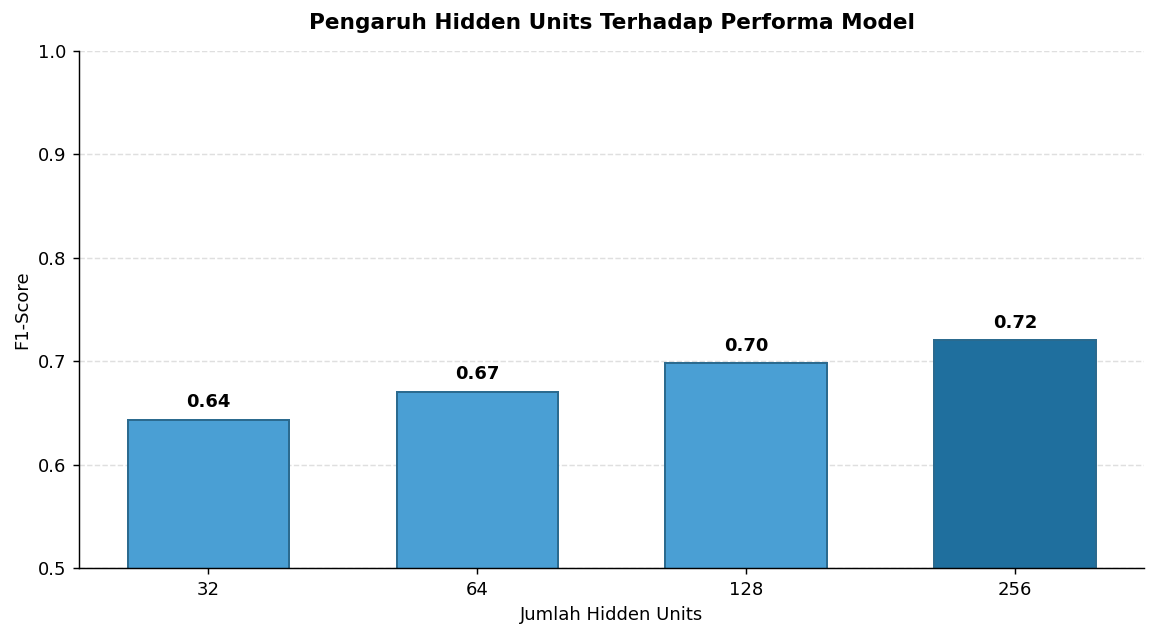

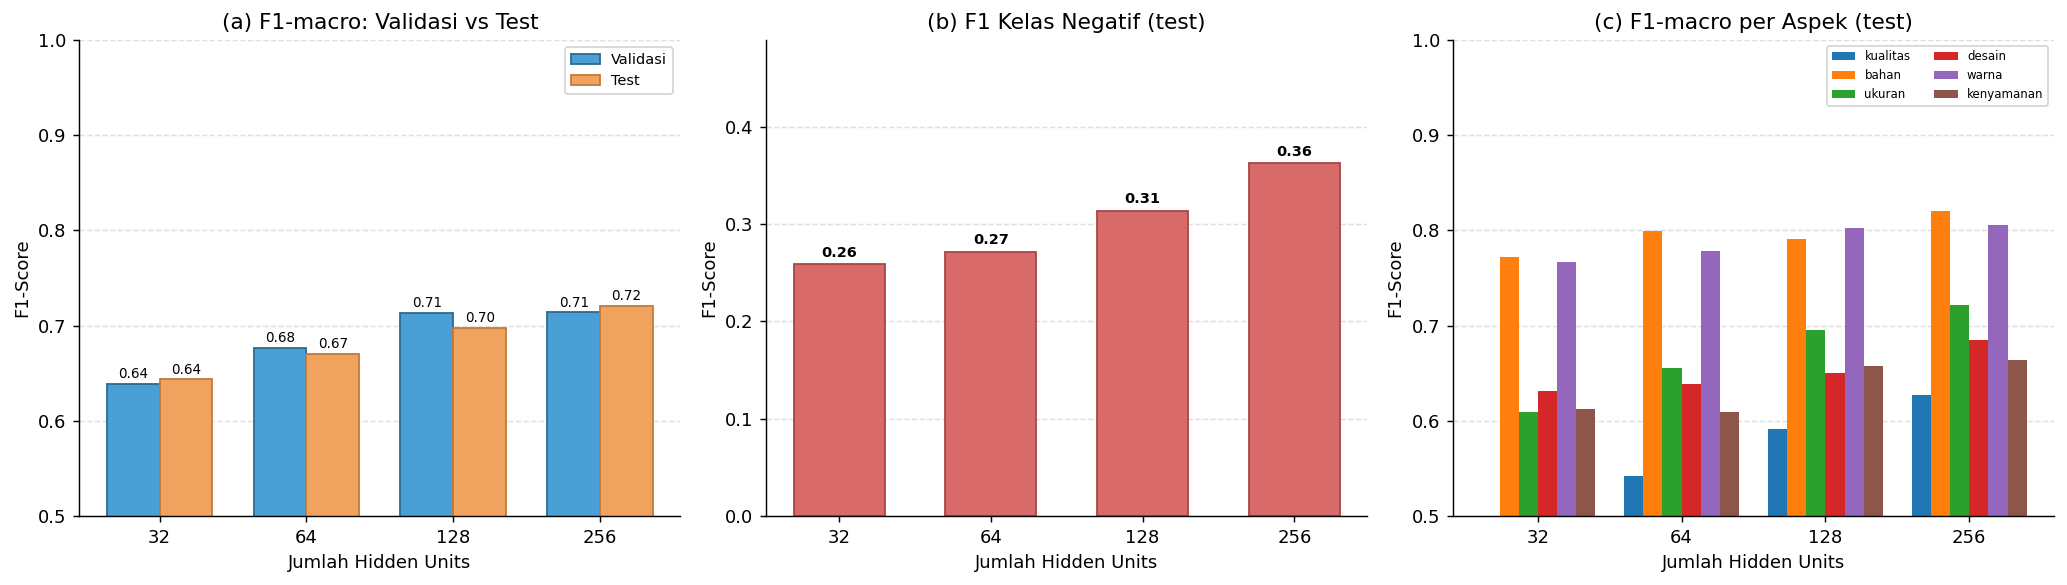


[OK] Disalin ke arsip: HASIL_FINAL_20260720_0748
[OK] ZIP arsip diperbarui (21.6 MB)

[OK] Tersimpan di /content/drive/MyDrive/ABSA_LSTM/SWEEP_HIDDEN_UNITS_20260720_0749
[HASIL] Hidden units optimal = 256 (val F1-macro 0.7140)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Hidden units vs. performance analysis
import os, json, time, gc, glob, shutil, zipfile, datetime
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import f1_score

# ===== SETELAN =====
MODE = 'cepat'          # 'cepat' (~10-15 mnt) atau 'lengkap' (~60-75 mnt)

if MODE == 'cepat':
    UNITS_SWEEP, EPOCHS_SWEEP, BATCH_SWEEP, PATIENCE = [32, 64, 128, 256], 15, 128, 4
else:
    UNITS_SWEEP, EPOCHS_SWEEP, BATCH_SWEEP, PATIENCE = [32, 64, 96, 128, 192, 256], 25, 32, 6
SEED = 42

G = globals()
def ambil(*nama, wajib=False, default=None):
    for n in nama:
        if n in G and G[n] is not None: return G[n]
    if wajib: raise NameError(f'[GAGAL] Tidak ditemukan: {nama}')
    return default

ASPECTS   = ambil('ASPECTS', 'ASPEK', wajib=True)
MAX_LEN   = ambil('MAX_LEN', 'MAXLEN', 'max_len', default=100)
X_tr      = ambil('X_train_pad', 'X_train_padded', wajib=True)
X_va      = ambil('X_val_pad', 'X_val_padded',     wajib=True)
X_te      = ambil('X_test_pad', 'X_test_padded',   wajib=True)
y_tr      = ambil('y_train', wajib=True)
y_va      = ambil('y_val',   wajib=True)
y_te      = ambil('y_test',  wajib=True)
emb_mat   = ambil('embedding_matrix', 'emb_matrix', 'matriks_embedding')
tokenizer = ambil('tokenizer', 'tok', wajib=True)
VOCAB     = len(tokenizer.word_index) + 1
EMB_DIM   = emb_mat.shape[1] if emb_mat is not None else 200

STAMP = datetime.datetime.now().strftime('%Y%m%d_%H%M')
OUT   = f'/content/drive/MyDrive/ABSA_LSTM/SWEEP_HIDDEN_UNITS_{STAMP}'
os.makedirs(OUT, exist_ok=True)


class Attention(layers.Layer):
    """Additive (Bahdanau-style) attention pooling — kompatibel Keras 3."""
    def build(self, s):
        d = s[-1]
        self.W = self.add_weight(name='W', shape=(d, d),
                                 initializer='glorot_uniform', trainable=True)
        self.b = self.add_weight(name='b', shape=(d,),
                                 initializer='zeros', trainable=True)
        self.u = self.add_weight(name='u', shape=(d, 1),
                                 initializer='glorot_uniform', trainable=True)
        super().build(s)

    def call(self, x):
        a = tf.nn.softmax(tf.matmul(tf.tanh(tf.matmul(x, self.W) + self.b),
                                    self.u), axis=1)
        return tf.reduce_sum(x * a, axis=1)

    def compute_output_shape(self, s):
        return (s[0], s[-1])


def bangun(units):
    inp = layers.Input(shape=(MAX_LEN,), name='input_teks')
    if emb_mat is not None:
        e = layers.Embedding(VOCAB, EMB_DIM, weights=[emb_mat],
                             trainable=False, mask_zero=False)(inp)
    else:
        e = layers.Embedding(VOCAB, EMB_DIM, mask_zero=False)(inp)
    e = layers.SpatialDropout1D(0.3)(e)
    h = layers.LSTM(units, return_sequences=True, dropout=0.2,
                    recurrent_dropout=0.0)(e)          # LSTM, bukan BiLSTM
    h = Attention()(h)
    h = layers.Dropout(0.4)(h)
    outs = []
    for a in ASPECTS:
        d = layers.Dense(max(32, units // 2), activation='relu')(h)
        d = layers.Dropout(0.3)(d)
        outs.append(layers.Dense(3, activation='softmax', name=f'output_{a}')(d))
    m = keras.Model(inp, outs)
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss={f'output_{a}': 'sparse_categorical_crossentropy' for a in ASPECTS},
              metrics=None)
    return m


print('=' * 74)
print(f'  SWEEP HIDDEN UNITS  [mode: {MODE}]')
print(f'  konfigurasi : {UNITS_SWEEP}')
print(f'  {EPOCHS_SWEEP} epoch | batch {BATCH_SWEEP} | patience {PATIENCE}')
print('=' * 74)
t_mulai = time.time()

hasil = []
for idx, u in enumerate(UNITS_SWEEP, 1):
    tf.keras.backend.clear_session(); gc.collect()
    tf.random.set_seed(SEED); np.random.seed(SEED)
    print(f'\n--- [{idx}/{len(UNITS_SWEEP)}] LSTM units = {u} ---')
    m = bangun(u)
    t0 = time.time()
    m.fit(X_tr, {f'output_{a}': y_tr[a] for a in ASPECTS},
          validation_data=(X_va, {f'output_{a}': y_va[a] for a in ASPECTS}),
          epochs=EPOCHS_SWEEP, batch_size=BATCH_SWEEP, verbose=0,
          callbacks=[keras.callbacks.EarlyStopping(
              monitor='val_loss', patience=PATIENCE, restore_best_weights=True)])
    durasi = time.time() - t0

    def nilai(X, y):
        p = m.predict(X, batch_size=256, verbose=0)
        if not isinstance(p, list): p = [p]
        mac, neg = [], []
        for i, a in enumerate(ASPECTS):
            yp = p[i].argmax(1); yt = np.asarray(y[a])
            mac.append(f1_score(yt, yp, average='macro', zero_division=0))
            neg.append(f1_score(yt, yp, labels=[2], average='macro', zero_division=0))
        return float(np.mean(mac)), float(np.mean(neg)), mac

    v_mac, v_neg, _     = nilai(X_va, y_va)
    t_mac, t_neg, per_a = nilai(X_te, y_te)
    r = {'units': u, 'parameter': int(m.count_params()),
         'val_f1_macro': v_mac, 'test_f1_macro': t_mac,
         'val_f1_negatif': v_neg, 'test_f1_negatif': t_neg,
         'detik': durasi}
    r.update({f'test_f1_{a}': per_a[i] for i, a in enumerate(ASPECTS)})
    hasil.append(r)
    sisa = (time.time() - t_mulai) / idx * (len(UNITS_SWEEP) - idx)
    print(f'  params={r["parameter"]:>9,} | val macro={v_mac:.4f} | '
          f'test macro={t_mac:.4f} | test neg={t_neg:.4f} | {durasi/60:.1f} mnt'
          f'   (sisa ~{sisa/60:.0f} mnt)')
    del m

df = pd.DataFrame(hasil)
df.to_csv(f'{OUT}/hasil_sweep_hidden_units.csv', index=False)

u_best = int(df.loc[df.val_f1_macro.idxmax(), 'units'])
print('\n' + '=' * 82)
print(f'{"Units":>6}|{"Parameter":>11}|{"Val macro":>10}|{"Test macro":>11}|'
      f'{"Test neg":>10}|{"Menit":>7}')
print('-' * 82)
for _, r in df.iterrows():
    tanda = '  <-- terbaik' if r['units'] == u_best else ''
    print(f'{int(r["units"]):>6}|{int(r["parameter"]):>11,}|{r["val_f1_macro"]:>10.4f}|'
          f'{r["test_f1_macro"]:>11.4f}|{r["test_f1_negatif"]:>10.4f}|'
          f'{r["detik"]/60:>7.1f}{tanda}')
print('=' * 82)
print(f'Total waktu sweep: {(time.time()-t_mulai)/60:.1f} menit')

# ---------- GRAFIK: DIAGRAM BATANG ----------
plt.rcParams.update({'figure.dpi': 130, 'savefig.bbox': 'tight',
                     'savefig.facecolor': 'white', 'font.size': 10})
best = u_best
x    = np.arange(len(df))
unit = [str(int(u)) for u in df.units]

# --- Grafik utama ---
fig, ax = plt.subplots(figsize=(9, 5))
warna = ['#4a9fd4' if u != best else '#1f6f9e' for u in df.units]
bar = ax.bar(x, df.test_f1_macro, width=0.6, color=warna,
             edgecolor='#2b6a8f', linewidth=1.1)
for b_, v in zip(bar, df.test_f1_macro):
    ax.text(b_.get_x() + b_.get_width()/2, v + 0.008, f'{v:.2f}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(unit)
ax.set_ylim(0.5, 1.0)
ax.set_xlabel('Jumlah Hidden Units'); ax.set_ylabel('F1-Score')
ax.set_title('Pengaruh Hidden Units Terhadap Performa Model',
             fontweight='bold', pad=12)
ax.grid(axis='y', ls='--', alpha=.4); ax.set_axisbelow(True)
for sisi in ('top', 'right'): ax.spines[sisi].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUT}/grafik_hidden_units.png')
plt.savefig(f'{OUT}/grafik_hidden_units.pdf')
plt.show()

# --- Grafik pendukung ---
fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
w = 0.36

p = ax[0]
p.bar(x - w/2, df.val_f1_macro,  w, label='Validasi', color='#4a9fd4',
      edgecolor='#2b6a8f')
p.bar(x + w/2, df.test_f1_macro, w, label='Test',     color='#f0a35e',
      edgecolor='#c47a37')
for i in range(len(df)):
    p.text(i - w/2, df.val_f1_macro.iloc[i] + .006,
           f'{df.val_f1_macro.iloc[i]:.2f}', ha='center', fontsize=7.5)
    p.text(i + w/2, df.test_f1_macro.iloc[i] + .006,
           f'{df.test_f1_macro.iloc[i]:.2f}', ha='center', fontsize=7.5)
p.set_ylim(0.5, 1.0); p.set_title('(a) F1-macro: Validasi vs Test')
p.legend(fontsize=8)

p = ax[1]
p.bar(x, df.test_f1_negatif, 0.6, color='#d96a6a', edgecolor='#a84545')
for i, v in enumerate(df.test_f1_negatif):
    p.text(i, v + .008, f'{v:.2f}', ha='center', fontsize=8, fontweight='bold')
p.set_ylim(0, max(df.test_f1_negatif) * 1.35)
p.set_title('(b) F1 Kelas Negatif (test)')

p = ax[2]
wa = 0.8 / len(ASPECTS)
for k, a in enumerate(ASPECTS):
    p.bar(x + (k - len(ASPECTS)/2 + .5) * wa, df[f'test_f1_{a}'], wa, label=a)
p.set_ylim(0.5, 1.0); p.set_title('(c) F1-macro per Aspek (test)')
p.legend(fontsize=6.5, ncol=2)

for p in ax:
    p.set_xticks(x); p.set_xticklabels(unit)
    p.set_xlabel('Jumlah Hidden Units'); p.set_ylabel('F1-Score')
    p.grid(axis='y', ls='--', alpha=.4); p.set_axisbelow(True)
    for sisi in ('top', 'right'): p.spines[sisi].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUT}/grafik_hidden_units_pendukung.png')
plt.savefig(f'{OUT}/grafik_hidden_units_pendukung.pdf')
plt.show()

# ---------- Ringkasan JSON ----------
json.dump({'mode': MODE,
           'units_terbaik': best,
           'f1_macro_terbaik': float(df.val_f1_macro.max()),
           'epoch_per_konfigurasi': EPOCHS_SWEEP,
           'batch_size': BATCH_SWEEP,
           'catatan': 'Sweep memakai anggaran epoch terbatas untuk perbandingan '
                      'relatif antar-konfigurasi; angka absolut lebih rendah '
                      'daripada model final yang dilatih penuh.',
           'hasil': df.to_dict('records')},
          open(f'{OUT}/ringkasan_sweep.json', 'w'), indent=2)

# ---------- Salin ke arsip + unduh ----------
arsip = [a for a in sorted(glob.glob('/content/drive/MyDrive/ABSA_LSTM/HASIL_FINAL_*'))
         if os.path.isdir(a)]
if arsip:
    tujuan = arsip[-1]
    os.makedirs(f'{tujuan}/grafik', exist_ok=True)
    os.makedirs(f'{tujuan}/metrik', exist_ok=True)
    salin = [
        ('grafik_hidden_units.png',            'grafik/08_hidden_units.png'),
        ('grafik_hidden_units.pdf',            'grafik/08_hidden_units.pdf'),
        ('grafik_hidden_units_pendukung.png',  'grafik/08b_hidden_units_pendukung.png'),
        ('grafik_hidden_units_pendukung.pdf',  'grafik/08b_hidden_units_pendukung.pdf'),
        ('hasil_sweep_hidden_units.csv',       'metrik/hasil_sweep_hidden_units.csv'),
        ('ringkasan_sweep.json',               'metrik/ringkasan_sweep.json'),
    ]
    for asal, ke in salin:
        shutil.copy(f'{OUT}/{asal}', f'{tujuan}/{ke}')
    print(f'\n[OK] Disalin ke arsip: {os.path.basename(tujuan)}')

    zip_arsip = f'{tujuan}.zip'
    with zipfile.ZipFile(zip_arsip, 'w', zipfile.ZIP_DEFLATED) as z:
        for root, _, files in os.walk(tujuan):
            for fn in files:
                fp = os.path.join(root, fn)
                z.write(fp, os.path.relpath(fp, tujuan))
    print(f'[OK] ZIP arsip diperbarui ({os.path.getsize(zip_arsip)/1e6:.1f} MB)')

zip_sweep = f'{OUT}.zip'
with zipfile.ZipFile(zip_sweep, 'w', zipfile.ZIP_DEFLATED) as z:
    for fn in os.listdir(OUT):
        z.write(os.path.join(OUT, fn), fn)

print(f'\n[OK] Tersimpan di {OUT}')
print(f'[HASIL] Hidden units optimal = {best} '
      f'(val F1-macro {df.val_f1_macro.max():.4f})')

try:
    from google.colab import files as colab_files
    colab_files.download(zip_sweep)
except Exception as e:
    print(f'[INFO] Unduh manual dari Drive: {zip_sweep}  ({e})')